# Echo State Networks hyperparameter and reservoir topology study II - on the NASDAQ dataset

**Notebook 4** of a research series framed within Antonio Macías Ferrera's Master's thesis
(*General Study of the Reservoir Topology on Echo State Networks*, University of Seville).

This notebook mirrors the analytical structure of **Notebook 2**, applying it to the
**NASDAQ Composite Index** (`^IXIC`) daily log-return series. Real-world financial data
introduces genuine non-stationarity, heavy tails, and volatility clustering — challenges
absent from both the ERA5 meteorological dataset and the controlled synthetic benchmark.

The notebook combines:
- **exploratory analysis** of the NASDAQ log-return series,
- **Phase A hyperparameter search** using strict 10-fold temporal cross-validation,
- a **detailed OAT sensitivity study** on each core hyperparameter,
- a **refined hyperparameter search** anchored on the OAT findings,
- and a **Phase B raw-topology study** on Erdős-Rényi, Watts-Strogatz, and Barabási-Albert reservoirs.


## Abstract

This notebook applies the ESN hyperparameter and topology study framework of Notebook 2 to
a **real-world financial time series**: the daily log-returns of the **NASDAQ Composite Index**
(`^IXIC`, Yahoo Finance) from January 2010 to December 2024.

Financial returns present distinct modelling challenges compared to meteorological or
synthetic data: they are approximately i.i.d. at the daily frequency, exhibit heavy tails,
volatility clustering, and structural breaks (flash crashes, crises). This makes the NASDAQ
dataset a useful stress test for how much temporal structure an ESN can extract from a
nearly unpredictable signal.

**Phase A** performs a grid search over the ESN hyperparameters
**reservoir size** `N`, **spectral radius** `sr`, **leak rate** `lr`,
**ridge regularisation** `ridge`, and **washout length** `washout`
using strict **10-fold temporal cross-validation** on the full NASDAQ log-return series.
Following the same workflow as Notebook 2, a one-at-a-time sensitivity analysis identifies
the most influential hyperparameters, and a **refined search** concentrates on the
best-performing region.

**Phase B** fixes the best Phase A configuration and studies the effect of
**reservoir graph topology** — Erdős-Rényi, Watts-Strogatz, Barabási-Albert — on
next-step log-return forecasting performance.

All figures and tables are written to `single_hp_outputs_4/`.

---


## Table of Contents

1. [Environment Setup](#1-environment-setup)
2. [NASDAQ Dataset Download and Preprocessing](#2-nasdaq-dataset-download-and-preprocessing)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
4. [Echo State Network Methodology](#4-echo-state-network-methodology)
5. [Phase A - Hyperparameter Study](#5-phase-a---hyperparameter-study)
   - 5.1. Grid search and results summary
   - 5.2. Detailed OAT sensitivity analysis
   - 5.3. Refined grid search anchored on the OAT findings
   - 5.4. Best-model prediction on the NASDAQ series
6. [Phase B - Reservoir Topology Study](#6-phase-b---reservoir-topology-study)
   - 6.1. Erdős-Rényi: sensitivity to edge probability `p`
   - 6.2. Watts-Strogatz: sensitivity to `k` and `p_rewire`
   - 6.3. Barabási-Albert: sensitivity to `m`
   - 6.4. Cross-topology comparison
7. [Conclusions](#7-conclusions)


## 1. Environment Setup

The following cell imports the libraries required to reproduce the NASDAQ study in the
local `.venv` kernel already used by the earlier notebooks.

Recommended local workflow:
1. Select `.venv` as the Python interpreter.
2. Open the notebook with the `.venv` Jupyter kernel.
3. Ensure these packages are available:
   - `reservoirpy`, `scikit-learn`, `numpy`, `pandas`, `scipy`
   - `matplotlib`, `seaborn`, `networkx`
   - `yfinance` — install with `pip install yfinance` if missing


In [34]:
# ---------------------------------------------------------------------------
# Standard library
# ---------------------------------------------------------------------------
import os
import time
import random
import warnings
from pathlib import Path

# ---------------------------------------------------------------------------
# Scientific computing
# ---------------------------------------------------------------------------
import numpy as np
import pandas as pd
from scipy import stats
from scipy.signal import periodogram

# ---------------------------------------------------------------------------
# Visualisation
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------------------------
# Machine learning utilities
# ---------------------------------------------------------------------------
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ---------------------------------------------------------------------------
# Graph generation
# ---------------------------------------------------------------------------
import networkx as nx

# ---------------------------------------------------------------------------
# Financial data
# ---------------------------------------------------------------------------
import yfinance as yf

# ---------------------------------------------------------------------------
# Reservoir computing
# ---------------------------------------------------------------------------
import reservoirpy as rpy
from reservoirpy.nodes import Reservoir, Ridge

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

print("Library versions")
print("----------------")
for lib_name, lib in [
    ("numpy", np),
    ("pandas", pd),
    ("yfinance", yf),
    ("reservoirpy", rpy),
    ("networkx", nx),
    ("seaborn", sns),
]:
    version = getattr(lib, "__version__", "n/a")
    print(f"  {lib_name:15s} {version}")


Library versions
----------------
  numpy           2.4.2
  pandas          3.0.1
  yfinance        1.3.0
  reservoirpy     0.4.1
  networkx        3.6.1
  seaborn         0.13.2


In [35]:
# ---------------------------------------------------------------------------
# Global configuration
# ---------------------------------------------------------------------------
N_SPLITS   = 10
LAG        = 10
TICKER     = "^IXIC"        # NASDAQ Composite Index
START_DATE = "2010-01-01"
END_DATE   = "2024-12-31"
OUTPUT_DIR = Path("single_hp_outputs_4")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Configuration loaded")
print(f"  CV folds       : {N_SPLITS}")
print(f"  Input lag      : {LAG}")
print(f"  Ticker         : {TICKER}")
print(f"  Date range     : {START_DATE} → {END_DATE}")
print(f"  Output folder  : {OUTPUT_DIR.resolve()}")


Configuration loaded
  CV folds       : 10
  Input lag      : 10
  Ticker         : ^IXIC
  Date range     : 2010-01-01 → 2024-12-31
  Output folder  : /Users/antoniommff/Developer/2_fase_experimentacion/single_hp_outputs_4


<br>

---

## 2. NASDAQ Dataset Download and Preprocessing

### Data Source

We use the **NASDAQ Composite Index** (`^IXIC`) daily closing prices from **Yahoo Finance**
via the `yfinance` library. The download covers **January 2010 – December 2024**, giving
approximately 3 750 trading-day observations.

### Why log-returns

Closing prices are non-stationary (strong upward trend). To obtain a series compatible with
the ESN forecasting setup used in Notebooks 1–3, we convert prices to **daily log-returns**:

$$r_t = \log\!\left(\frac{P_t}{P_{t-1}}\right)$$

Log-returns are approximately stationary and their distribution is well-studied. The ESN
is trained to predict the next-day log-return $r_{t+1}$ from the lag-10 window
$[r_{t-9}, \ldots, r_t]$.

### Preprocessing steps

1. Download daily adjusted `Close` prices via `yfinance.download`.
2. Compute log-returns and drop the first NaN row.
3. Validate that no missing or infinite values remain.
4. Build a tidy `DataFrame` indexed by trading date.


In [36]:
# ---------------------------------------------------------------------------
# Download NASDAQ Composite closing prices and compute log-returns
# ---------------------------------------------------------------------------
raw = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)
close_prices = raw["Close"].squeeze().dropna()

log_returns   = np.log(close_prices / close_prices.shift(1)).dropna()
nasdaq_series = log_returns.values.astype(np.float64)
nasdaq_dates  = log_returns.index

df = pd.DataFrame({"log_return": nasdaq_series}, index=nasdaq_dates)

print(f"Download complete")
print(f"  Ticker              : {TICKER}")
print(f"  Period              : {nasdaq_dates[0].date()} → {nasdaq_dates[-1].date()}")
print(f"  Trading days        : {len(df):,}")
print(f"  Closing price range : {close_prices.min():.2f} – {close_prices.max():.2f}")
print(f"\nFirst 5 log-returns:")
print(df.head().to_string())


Download complete
  Ticker              : ^IXIC
  Period              : 2010-01-05 → 2024-12-30
  Trading days        : 3,772
  Closing price range : 2091.79 – 20173.89

First 5 log-returns:
            log_return
Date                  
2010-01-05    0.000126
2010-01-06   -0.003306
2010-01-07   -0.000452
2010-01-08    0.007416
2010-01-11   -0.002056


### Missing-value strategy

Yahoo Finance delivers data only for trading days (weekends and public holidays excluded).
The series is **complete by construction** within that calendar — there are no gap-day NaNs.

We apply the same hygiene as in Notebook 2:

1. Validate that `log_return` contains no `NaN` or infinite values.
2. Confirm the series length matches expectations (~252 trading days per year).
3. Print summary statistics to verify the distributional properties expected of log-returns
   (near-zero mean, small standard deviation, heavy tails).


In [37]:
# ---------------------------------------------------------------------------
# Validate the NASDAQ series and print summary statistics
# ---------------------------------------------------------------------------
n_missing  = df["log_return"].isna().sum()
n_infinite = np.isinf(df["log_return"]).sum()

print(f"Total trading days in dataset : {len(df):,}")
print(f"Missing values                : {n_missing}")
print(f"Infinite values               : {n_infinite}")

if n_missing > 0 or n_infinite > 0:
    raise ValueError("NASDAQ series contains invalid values.")

summary = df.describe().T
summary["skewness"]        = stats.skew(df["log_return"].values, bias=False)
summary["excess_kurtosis"] = stats.kurtosis(df["log_return"].values, fisher=True, bias=False)
print("\nSummary statistics\n")
print(summary.to_string(float_format=lambda x: f"{x:.6f}"))


Total trading days in dataset : 3,772
Missing values                : 0
Infinite values               : 0

Summary statistics

                 count     mean      std       min       25%      50%      75%      max  skewness  excess_kurtosis
log_return 3772.000000 0.000566 0.012789 -0.131492 -0.004830 0.001064 0.007248 0.089347 -0.597292         7.411079


<br>

---

## 3. Exploratory Data Analysis

The goal of this section is the same as in Notebook 2: understand the structure of the
data before touching the ESN.

For the NASDAQ log-return series, four views matter:
1. **closing price trajectory** — the raw level series showing the long-term trend and crises,
2. **log-return time series** — the actual ESN input, showing volatility clustering,
3. **marginal distribution** — fat tails and departure from Gaussianity,
4. **rolling volatility and periodogram** — non-stationarity in variance and frequency content.


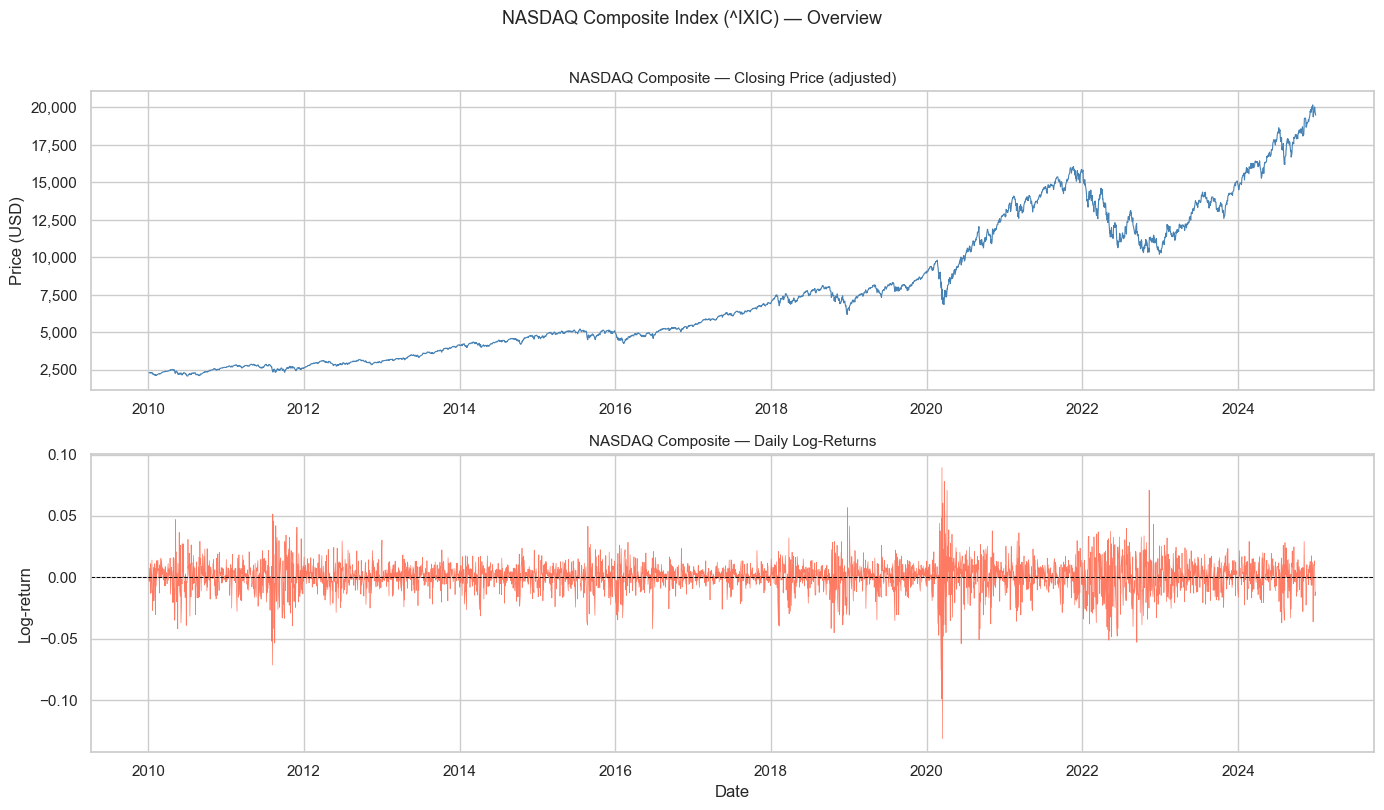

Figure saved  single_hp_outputs_4/nasdaq_series_overview.png


In [38]:
# ---------------------------------------------------------------------------
# NASDAQ overview: closing price + log-returns
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

ax = axes[0]
ax.plot(close_prices.index, close_prices.values, lw=0.8, color="steelblue")
ax.set_title("NASDAQ Composite — Closing Price (adjusted)", fontsize=11)
ax.set_ylabel("Price (USD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

ax = axes[1]
ax.plot(nasdaq_dates, nasdaq_series, lw=0.5, color="tomato", alpha=0.85)
ax.axhline(0, color="black", lw=0.7, ls="--")
ax.set_title("NASDAQ Composite — Daily Log-Returns", fontsize=11)
ax.set_ylabel("Log-return")
ax.set_xlabel("Date")

fig.suptitle("NASDAQ Composite Index (^IXIC) — Overview", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "nasdaq_series_overview.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Figure saved  {OUTPUT_DIR / 'nasdaq_series_overview.png'}")


The two panels above characterise the input data:

- The **closing price** (top) shows the secular upward trend punctuated by the 2020 COVID
  crash, the 2022 rate-hike correction, and the recovery through 2024. This non-stationarity
  is why we work with log-returns rather than raw prices.
- The **log-return series** (bottom) is approximately centred on zero and shows clear
  **volatility clustering**: quiet periods of small moves alternate with crisis episodes of
  large positive and negative returns — a signature of GARCH-type dynamics that an ESN's
  fading-memory state should partially capture.


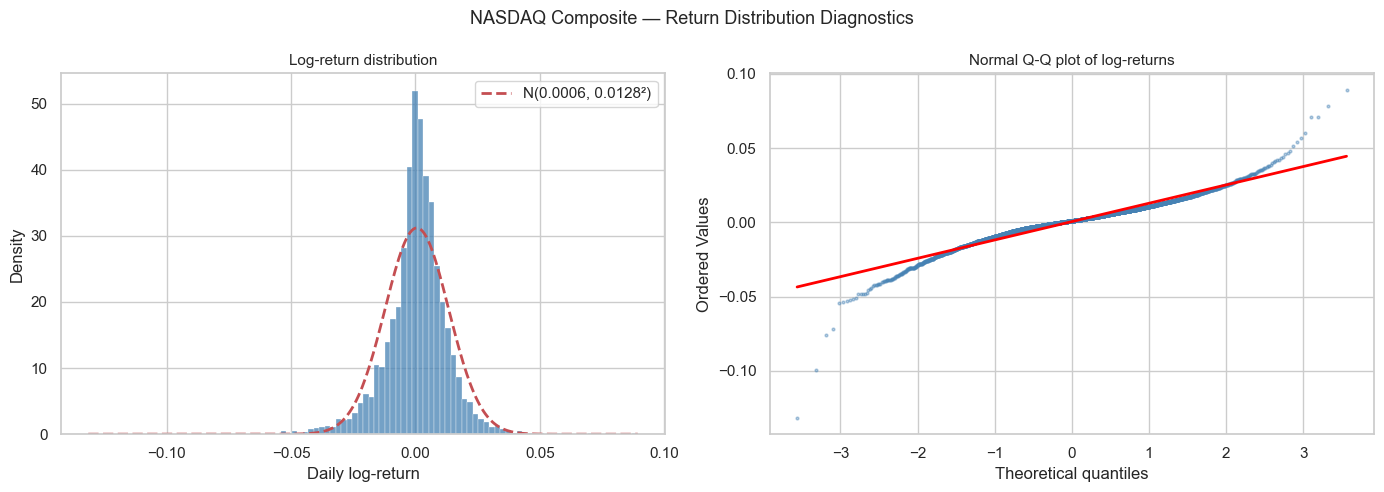

Figure saved  single_hp_outputs_4/nasdaq_distribution.png


In [39]:
# ---------------------------------------------------------------------------
# Log-return distribution and Q-Q plot
# ---------------------------------------------------------------------------
from scipy.stats import norm, probplot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(nasdaq_series, bins=100, density=True, alpha=0.75, color="steelblue",
        edgecolor="white", lw=0.3)
mu, sigma = nasdaq_series.mean(), nasdaq_series.std()
x_grid = np.linspace(nasdaq_series.min(), nasdaq_series.max(), 300)
ax.plot(x_grid, norm.pdf(x_grid, mu, sigma), "r--", lw=2,
        label=f"N({mu:.4f}, {sigma:.4f}²)")
ax.set_title("Log-return distribution", fontsize=11)
ax.set_xlabel("Daily log-return")
ax.set_ylabel("Density")
ax.legend()

ax = axes[1]
probplot(nasdaq_series, dist="norm", plot=ax)
ax.set_title("Normal Q-Q plot of log-returns", fontsize=11)
ax.get_lines()[0].set(markersize=2, alpha=0.4, color="steelblue")
ax.get_lines()[1].set(color="red", lw=2)

fig.suptitle("NASDAQ Composite — Return Distribution Diagnostics", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "nasdaq_distribution.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Figure saved  {OUTPUT_DIR / 'nasdaq_distribution.png'}")


The two distribution diagnostics reveal the classic properties of financial returns:

- The **histogram** (left) is more peaked at zero and has heavier tails than the fitted
  Gaussian (dashed red). This leptokurtosis is the main challenge for any model that assumes
  Gaussian residuals.
- The **Q-Q plot** (right) confirms the heavy-tail deviation: both tails deviate strongly
  from the reference line, indicating that extreme moves happen far more often than a normal
  distribution predicts.

These properties motivate caution when interpreting RMSE: a heavy-tailed error distribution
means that one or two large-magnitude predictions can dominate the aggregate metric.


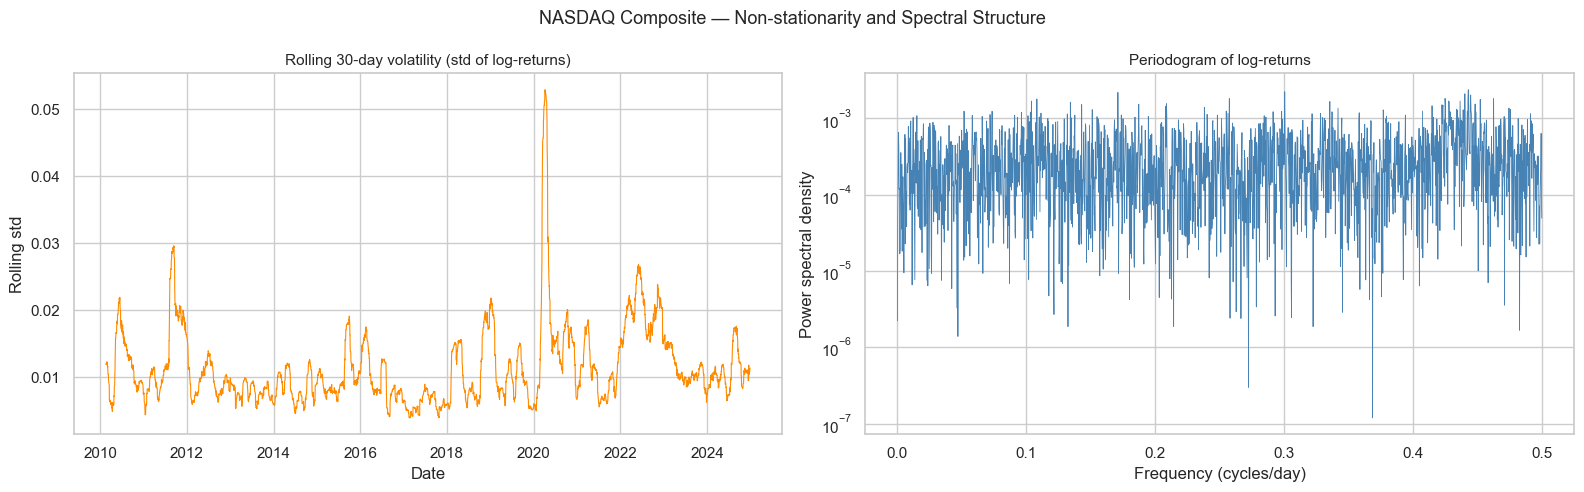

Figure saved  single_hp_outputs_4/nasdaq_complexity.png


In [40]:
# ---------------------------------------------------------------------------
# Complexity diagnostics:
#   1. Rolling 30-day volatility (std of log-returns)
#   2. Periodogram
# ---------------------------------------------------------------------------
rolling_window = 30
rolling_vol = pd.Series(nasdaq_series, index=nasdaq_dates).rolling(rolling_window).std()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(nasdaq_dates, rolling_vol.values, lw=0.8, color="darkorange")
ax.set_title(f"Rolling {rolling_window}-day volatility (std of log-returns)", fontsize=11)
ax.set_xlabel("Date")
ax.set_ylabel("Rolling std")

ax = axes[1]
freqs, power = periodogram(nasdaq_series, fs=1.0)
ax.semilogy(freqs[1:], power[1:], lw=0.6, color="steelblue")
ax.set_title("Periodogram of log-returns", fontsize=11)
ax.set_xlabel("Frequency (cycles/day)")
ax.set_ylabel("Power spectral density")

fig.suptitle("NASDAQ Composite — Non-stationarity and Spectral Structure", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "nasdaq_complexity.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Figure saved  {OUTPUT_DIR / 'nasdaq_complexity.png'}")


The two diagnostics characterise the non-stationarity and spectral structure:

- The **rolling volatility** (left) shows GARCH-like clustering: the 2020 COVID crash
  produces a sharp spike; the 2022 correction shows elevated sustained volatility. The
  reservoir's fading memory should partially track these regime changes.
- The **periodogram** (right) is approximately flat — consistent with a nearly uncorrelated
  daily return series. There is no dominant frequency peak, meaning the ESN cannot exploit
  periodic patterns. Performance will depend on subtle short-lag autocorrelations and
  volatility persistence.

This establishes the forecasting context: NASDAQ is a harder prediction target than ERA5
temperature, but a more realistic one for financial applications.


<br>

---

## 4. Echo State Network Methodology

### 4.1. Supervised Dataset Construction

The NASDAQ log-return series is treated as a **1-D univariate forecasting task**. As in
Notebook 2, we construct a lagged input window of length `L = 10` and predict the next
timestep.

For the log-return series $r_t$:

$$\mathbf{x}_t = [r_{t-9}, r_{t-8}, \ldots, r_{t-1}, r_t] \in \mathbb{R}^{10}$$

$$y_t = r_{t+1}$$

The series is standardised with `StandardScaler` (fit on training folds only) before
being fed to the reservoir, exactly as in Notebooks 1 and 2.


In [41]:
# ---------------------------------------------------------------------------
# Supervised lag-input dataset for the NASDAQ log-return series
# ---------------------------------------------------------------------------
def build_dataset(signal, lag=LAG):
    signal = np.asarray(signal)
    t_len = len(signal)
    X = np.column_stack([signal[i : t_len - lag + i] for i in range(lag)])
    y = signal[lag:].reshape(-1, 1)
    return X, y


X_nasdaq, y_nasdaq = build_dataset(nasdaq_series, lag=LAG)

print(f"NASDAQ supervised dataset")
print(f"  Feature matrix shape : {X_nasdaq.shape}")
print(f"  Target vector shape  : {y_nasdaq.shape}")
print(f"  Date range (inputs)  : {nasdaq_dates[LAG-1].date()} → {nasdaq_dates[-2].date()}")


NASDAQ supervised dataset
  Feature matrix shape : (3762, 10)
  Target vector shape  : (3762, 1)
  Date range (inputs)  : 2010-01-19 → 2024-12-27


### 4.2. Overview of Reservoir Computing

Echo State Networks transform each lag window into a high-dimensional recurrent state:

$$\mathbf{h}_t = (1 - \alpha)\,\mathbf{h}_{t-1}
+ \alpha \tanh \left( W_{in}\mathbf{x}_t + W\mathbf{h}_{t-1} \right)$$

where:
- $N$ controls the size of the reservoir,
- $\rho(W)$ controls the dynamical timescale and stability,
- $\alpha$ controls how quickly the state reacts to new input,
- the readout is fitted with ridge regression.

For the NASDAQ log-return series, the key challenge is that daily returns are nearly
unpredictable at the 1-step horizon. The ESN is expected to capture **volatility
persistence** (large returns tend to be followed by large returns, regardless of sign)
and any weak **autocorrelation** in the return series. The reservoir's fading memory
is the natural mechanism for this.


<br>

---

## 5. Phase A - Hyperparameter Study

We perform a **grid search** over the NASDAQ log-return series, reusing the same
Phase-A hyperparameter grid as Notebooks 1 and 2:

1. evaluate the Cartesian ESN grid under strict temporal CV on the NASDAQ series,
2. extract the best configuration,
3. run the Notebook-2-style detailed **one-at-a-time (OAT)** sensitivity analysis,
4. refine the search around the best-performing operating region.


In [42]:
# ---------------------------------------------------------------------------
# Phase A hyperparameter space
# ---------------------------------------------------------------------------
param_grid = {
    "N":       [3, 50, 100, 500],
    "sr":      [0.7, 0.9, 1.1],
    "lr":      [0.1, 0.3, 0.7],
    "ridge":   [1e-8, 1e-6, 1e-2],
    "washout": [50, 100],
}

total_grid_size = 1
for values in param_grid.values():
    total_grid_size *= len(values)

sampled_configs = list(ParameterGrid(param_grid))
total_evals = len(sampled_configs) * N_SPLITS

print(f"Full grid size    : {total_grid_size} configurations")
print(f"Sampled configs   : {len(sampled_configs)}")
print(f"Total model fits  : {total_evals}  ({len(sampled_configs)} configs × {N_SPLITS} folds)")


Full grid size    : 216 configurations
Sampled configs   : 216
Total model fits  : 2160  (216 configs × 10 folds)


In [43]:
# ---------------------------------------------------------------------------
# Phase A helpers and grid search on the NASDAQ series
# ---------------------------------------------------------------------------
def run_esn_cv_search(X, y, configs, signal_name, n_splits=N_SPLITS):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    results = []
    total = len(configs) * n_splits
    done = 0
    t0_all = time.time()

    for cfg_idx, cfg in enumerate(configs):
        for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X)):
            done += 1
            X_tr_f, y_tr_f = X[train_idx], y[train_idx]
            X_te_f, y_te_f = X[test_idx], y[test_idx]

            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_tr_f)
            X_te = scaler.transform(X_te_f)

            try:
                t0 = time.time()
                reservoir = Reservoir(
                    units=int(cfg["N"]),
                    sr=cfg["sr"],
                    lr=cfg["lr"],
                )
                model = reservoir >> Ridge(ridge=cfg["ridge"])
                model.fit(X_tr, y_tr_f, warmup=int(cfg["washout"]))
                y_pred = np.asarray(model.run(X_te)).reshape(-1)
                y_true = y_te_f.ravel()

                results.append({
                    "signal": signal_name,
                    "config_idx": cfg_idx,
                    "fold": fold_idx,
                    "N": int(cfg["N"]),
                    "sr": float(cfg["sr"]),
                    "lr": float(cfg["lr"]),
                    "ridge": float(cfg["ridge"]),
                    "washout": int(cfg["washout"]),
                    "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
                    "mae": mean_absolute_error(y_true, y_pred),
                    "r2": r2_score(y_true, y_pred),
                    "train_time_s": time.time() - t0,
                    "n_train": len(train_idx),
                    "n_test": len(test_idx),
                })
            except Exception as exc:
                results.append({
                    "signal": signal_name,
                    "config_idx": cfg_idx,
                    "fold": fold_idx,
                    "N": int(cfg["N"]),
                    "sr": float(cfg["sr"]),
                    "lr": float(cfg["lr"]),
                    "ridge": float(cfg["ridge"]),
                    "washout": int(cfg["washout"]),
                    "rmse": np.nan, "mae": np.nan, "r2": np.nan,
                    "train_time_s": np.nan,
                    "n_train": len(train_idx), "n_test": len(test_idx),
                    "error": str(exc),
                })

        if (cfg_idx + 1) % 20 == 0 or cfg_idx == 0:
            elapsed = time.time() - t0_all
            rate = done / elapsed if elapsed > 0 else np.nan
            print(
                f"    [{signal_name}] {cfg_idx + 1:3d}/{len(configs)} configs"
                f" | elapsed={elapsed/60:.1f} min | rate={rate:.2f} eval/s"
            )

    return pd.DataFrame(results)


def aggregate_phase_a(df):
    group_cols = ["signal", "config_idx", "N", "sr", "lr", "ridge", "washout"]
    return (
        df.dropna(subset=["rmse"])
        .groupby(group_cols)
        .agg(
            rmse_mean=("rmse", "mean"),
            rmse_std=("rmse", "std"),
            mae_mean=("mae", "mean"),
            mae_std=("mae", "std"),
            r2_mean=("r2", "mean"),
            r2_std=("r2", "std"),
            train_time_mean=("train_time_s", "mean"),
            n_folds=("fold", "count"),
        )
        .reset_index()
        .sort_values("rmse_mean")
    )


def params_from_row(row):
    return {
        "N": int(row["N"]),
        "sr": float(row["sr"]),
        "lr": float(row["lr"]),
        "ridge": float(row["ridge"]),
        "washout": int(row["washout"]),
    }


print(f"\n{'=' * 68}")
print(f"Phase A grid search - NASDAQ Composite ({TICKER})")
print(f"{'=' * 68}")
df_phase_a = run_esn_cv_search(X_nasdaq, y_nasdaq, sampled_configs, signal_name="NASDAQ")
agg_phase_a = aggregate_phase_a(df_phase_a)

df_phase_a.to_csv(OUTPUT_DIR / "phase_a_grid_search_fold_results.csv", index=False)
agg_phase_a.to_csv(OUTPUT_DIR / "phase_a_grid_search_summary.csv", index=False)

print(f"\nFold-level results saved  {OUTPUT_DIR / 'phase_a_grid_search_fold_results.csv'}")
print(f"Aggregate summary saved   {OUTPUT_DIR / 'phase_a_grid_search_summary.csv'}")



Phase A grid search - NASDAQ Composite (^IXIC)
    [NASDAQ]   1/216 configs | elapsed=0.0 min | rate=25.82 eval/s
    [NASDAQ]  20/216 configs | elapsed=0.1 min | rate=33.44 eval/s
    [NASDAQ]  40/216 configs | elapsed=0.2 min | rate=34.05 eval/s
    [NASDAQ]  60/216 configs | elapsed=0.3 min | rate=33.59 eval/s
    [NASDAQ]  80/216 configs | elapsed=0.4 min | rate=32.09 eval/s
    [NASDAQ] 100/216 configs | elapsed=0.5 min | rate=31.13 eval/s
    [NASDAQ] 120/216 configs | elapsed=0.7 min | rate=29.05 eval/s
    [NASDAQ] 140/216 configs | elapsed=0.9 min | rate=27.24 eval/s
    [NASDAQ] 160/216 configs | elapsed=1.1 min | rate=25.31 eval/s
    [NASDAQ] 180/216 configs | elapsed=1.6 min | rate=18.23 eval/s
    [NASDAQ] 200/216 configs | elapsed=2.2 min | rate=15.07 eval/s

Fold-level results saved  single_hp_outputs_4/phase_a_grid_search_fold_results.csv
Aggregate summary saved   single_hp_outputs_4/phase_a_grid_search_summary.csv


<br>

<br>

### 5.1. Phase A - Results Summary


In [44]:
# ---------------------------------------------------------------------------
# Best configuration from Phase A grid search
# ---------------------------------------------------------------------------
best_row = agg_phase_a.sort_values("rmse_mean").iloc[0]
best_params = params_from_row(best_row)

agg_phase_a.to_csv(OUTPUT_DIR / "phase_a_best_config.csv", index=False)

print("Top 10 Phase-A configurations (NASDAQ)\n")
display_cols = ["N", "sr", "lr", "ridge", "washout", "rmse_mean", "rmse_std", "r2_mean", "r2_std"]
print(agg_phase_a[display_cols].head(10).to_string(index=False, float_format=lambda x: f"{x:.5f}"))

print(f"\nBest configuration: {best_params}")
print(f"  RMSE = {best_row['rmse_mean']:.5f} ± {best_row['rmse_std']:.5f}")
print(f"  R²   = {best_row['r2_mean']:.5f} ± {best_row['r2_std']:.5f}")


Top 10 Phase-A configurations (NASDAQ)

 N      sr      lr   ridge  washout  rmse_mean  rmse_std  r2_mean  r2_std
 3 0.90000 0.10000 0.01000       50    0.01233   0.00401  0.00064 0.00305
 3 0.90000 0.30000 0.01000       50    0.01233   0.00399 -0.00060 0.00561
 3 0.70000 0.10000 0.00000      100    0.01233   0.00402  0.00007 0.00286
 3 0.70000 0.10000 0.00000       50    0.01233   0.00401 -0.00047 0.00414
 3 1.10000 0.30000 0.01000      100    0.01234   0.00401 -0.00096 0.00385
 3 1.10000 0.70000 0.00000      100    0.01234   0.00399 -0.00164 0.00399
 3 0.70000 0.70000 0.00000       50    0.01234   0.00401 -0.00094 0.00272
 3 1.10000 0.30000 0.00000       50    0.01234   0.00400 -0.00156 0.00438
 3 0.70000 0.30000 0.00000      100    0.01234   0.00401 -0.00144 0.00318
 3 0.70000 0.10000 0.00000       50    0.01234   0.00400 -0.00195 0.00705

Best configuration: {'N': 3, 'sr': 0.9, 'lr': 0.1, 'ridge': 0.01, 'washout': 50}
  RMSE = 0.01233 ± 0.00401
  R²   = 0.00064 ± 0.00305


The table above gives the **best achievable baseline** for the NASDAQ log-return series
under the Phase A grid. Because daily returns are nearly unpredictable, we expect a
relatively modest R² and RMSE close to the unconditional standard deviation of returns.

The best hyperparameter set from this phase is used as the **fixed starting point** for
the detailed OAT sensitivity analysis below.


In [45]:
import os as _os

_os.makedirs(OUTPUT_DIR, exist_ok=True)

def run_single_hp_study(X, y, hp_name, hp_values, base_params, n_splits=N_SPLITS, save_csv=None):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    records = []
    total = len(hp_values) * n_splits
    print(
        f"Single Hyperparameter Study '{hp_name}': {len(hp_values)} values x {n_splits} folds = {total} evaluations"
    )

    for val in hp_values:
        cfg = {**base_params, hp_name: val}
        for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X)):
            X_tr_f, y_tr_f = X[train_idx], y[train_idx]
            X_te_f, y_te_f = X[test_idx], y[test_idx]

            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_tr_f)
            X_te = scaler.transform(X_te_f)

            try:
                t0 = time.time()
                reservoir = Reservoir(units=int(cfg["N"]), sr=cfg["sr"], lr=cfg["lr"])
                model = reservoir >> Ridge(ridge=cfg["ridge"])
                model.fit(X_tr, y_tr_f, warmup=int(cfg["washout"]))
                y_pred = np.asarray(model.run(X_te)).reshape(-1)
                y_true = y_te_f.ravel()

                records.append({
                    hp_name: val,
                    "fold": fold_idx,
                    "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
                    "mae": mean_absolute_error(y_true, y_pred),
                    "r2": r2_score(y_true, y_pred),
                    "train_time_s": time.time() - t0,
                })
            except Exception as exc:
                print(f"  [ERROR] {hp_name}={val}, fold {fold_idx}: {exc}")
                records.append({hp_name: val, "fold": fold_idx,
                                "rmse": np.nan, "mae": np.nan, "r2": np.nan,
                                "train_time_s": np.nan})

    df_out = pd.DataFrame(records)
    if save_csv is not None:
        df_out.to_csv(save_csv, index=False)
        print(f"  CSV saved  {save_csv}")
    return df_out


def plot_single_hp(df, hp_name, hp_values, label_map=None, title=None, palette="colorblind", save_path=None):
    labels = [label_map[v] if label_map else str(v) for v in hp_values]
    df_plot = df.dropna(subset=["rmse"]).copy()
    df_plot["_lbl"] = df_plot[hp_name].map(dict(zip(hp_values, labels)))

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    if title:
        fig.suptitle(title, fontsize=11, fontweight="bold", y=1.01)

    ax = axes[0]
    sns.boxplot(data=df_plot, x="_lbl", y="rmse", order=labels, palette=palette,
                width=0.5, fliersize=0, ax=ax)
    sns.stripplot(data=df_plot, x="_lbl", y="rmse", order=labels, color="black",
                  size=4, alpha=0.6, jitter=True, ax=ax)
    ax.set_xlabel(hp_name); ax.set_ylabel("RMSE")
    ax.set_title("RMSE - fold distribution")
    ax.tick_params(axis="x", rotation=45)

    ax = axes[1]
    summary = (df_plot.groupby("_lbl")["rmse"].agg(["mean", "std"])
               .reindex(labels).reset_index())
    ax.errorbar(summary["_lbl"], summary["mean"], yerr=summary["std"],
                marker="o", capsize=6, linewidth=2, markersize=8,
                color="steelblue", elinewidth=1.5)
    ax.set_xlabel(hp_name); ax.set_ylabel("Mean RMSE ± std")
    ax.set_title("Mean RMSE ± std across folds")
    ax.tick_params(axis="x", rotation=45)

    ax = axes[2]
    sns.boxplot(data=df_plot, x="_lbl", y="r2", order=labels, palette=palette,
                width=0.5, fliersize=0, ax=ax)
    sns.stripplot(data=df_plot, x="_lbl", y="r2", order=labels, color="black",
                  size=4, alpha=0.6, jitter=True, ax=ax)
    ax.set_xlabel(hp_name); ax.set_ylabel("R²")
    ax.set_title("R² - fold distribution")
    ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=130, bbox_inches="tight")
        print(f"  Figure saved  {save_path}")
    plt.show()


def best_setting(df, param_name):
    agg = df.dropna(subset=["rmse"]).groupby(param_name)["rmse"].mean()
    return agg.idxmin()


def evaluate_holdout_prediction(signal, model_cfg, test_frac=0.25, W_custom=None):
    X_all, y_all = build_dataset(signal, lag=LAG)
    n = len(X_all)
    n_train = int(n * (1 - test_frac))

    X_train, y_train = X_all[:n_train], y_all[:n_train]
    X_test,  y_test  = X_all[n_train:], y_all[n_train:]

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train)
    X_te = scaler.transform(X_test)

    if W_custom is None:
        reservoir = Reservoir(units=model_cfg["N"], sr=model_cfg["sr"], lr=model_cfg["lr"])
    else:
        reservoir = Reservoir(units=model_cfg["N"], W=W_custom, lr=model_cfg["lr"])

    model = reservoir >> Ridge(ridge=model_cfg["ridge"])
    model.fit(X_tr, y_train, warmup=int(model_cfg["washout"]))
    y_pred = np.asarray(model.run(X_te)).reshape(-1)
    y_true = y_test.ravel()

    return {
        "y_true": y_true, "y_pred": y_pred,
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
        "n_train": n_train,
    }


def plot_nasdaq_prediction(model_cfg, title, test_frac=0.25, zoom=150,
                           W_custom=None, ax_row=None, save_path=None):
    metrics = evaluate_holdout_prediction(nasdaq_series, model_cfg,
                                          test_frac=test_frac, W_custom=W_custom)
    y_true  = metrics["y_true"]
    y_pred  = metrics["y_pred"]
    n_train = metrics["n_train"]

    t_full = np.arange(len(nasdaq_series))
    t_test = t_full[LAG + n_train:]

    own_fig = ax_row is None
    if own_fig:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    else:
        axes = ax_row

    ax = axes[0]
    ax.plot(t_full[: LAG + n_train], nasdaq_series[: LAG + n_train],
            lw=0.3, color="lightgray", label="Training series")
    ax.plot(t_test, y_true,  lw=0.8, color="steelblue", label="Real (test)")
    ax.plot(t_test, y_pred,  lw=0.8, color="tomato", alpha=0.85, label="Predicted")
    ax.axvline(LAG + n_train, color="black", ls="--", lw=0.8)
    ax.set_title(
        f"{title}\nRMSE={metrics['rmse']:.5f} | MAE={metrics['mae']:.5f} | R²={metrics['r2']:.4f}",
        fontsize=9,
    )
    ax.set_xlabel("Trading day index")
    ax.set_ylabel("Log-return")
    ax.legend(fontsize=7, loc="upper left")

    ax = axes[1]
    ax.plot(t_test[:zoom], y_true[:zoom], lw=1.1, color="steelblue", label="Real")
    ax.plot(t_test[:zoom], y_pred[:zoom], lw=1.1, color="tomato", ls="--", label="Predicted")
    ax.set_title(f"Zoom — first {zoom} test days", fontsize=9)
    ax.set_xlabel("Trading day index")
    ax.set_ylabel("Log-return")
    ax.legend(fontsize=7)

    if own_fig:
        plt.tight_layout()
        if save_path is not None:
            plt.savefig(save_path, dpi=130, bbox_inches="tight")
            print(f"Figure saved  {save_path}")
        plt.show()

    return metrics


print(f"Best Phase-A configuration for NASDAQ: {best_params}")


Best Phase-A configuration for NASDAQ: {'N': 3, 'sr': 0.9, 'lr': 0.1, 'ridge': 0.01, 'washout': 50}


### 5.2. Phase A - Hyperparameter Sensitivity Analysis

With the best configuration fixed from the grid search, we reproduce Notebook 2's
**one-at-a-time (OAT) sensitivity workflow** on the NASDAQ log-return series.
Each hyperparameter is swept across a broad range while the other four remain fixed at
the best grid-search values.

This isolates the marginal effect of each hyperparameter on the NASDAQ forecasting task.


Single Hyperparameter Study 'N': 10 values x 10 folds = 100 evaluations
  CSV saved  single_hp_outputs_4/shs_N.csv
  Figure saved  single_hp_outputs_4/shs_N.png


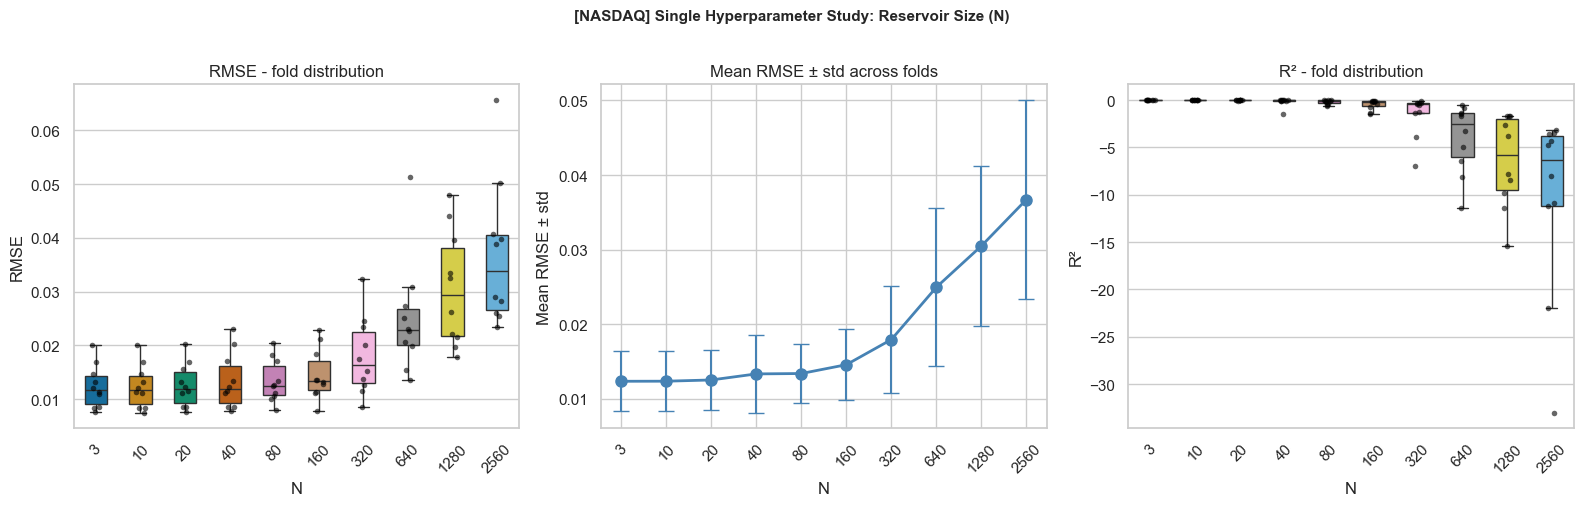

In [46]:
# Single Hyperparameter Study: Reservoir Size (N)
N_values = [3, 10, 20, 40, 80, 160, 320, 640, 1280, 2560]
df_shs_N = run_single_hp_study(
    X_nasdaq, y_nasdaq, "N", N_values, best_params,
    save_csv=OUTPUT_DIR / "shs_N.csv",
)
plot_single_hp(
    df_shs_N,
    "N",
    N_values,
    title="[NASDAQ] Single Hyperparameter Study: Reservoir Size (N)",
    save_path=OUTPUT_DIR / "shs_N.png",
)


#### 5.2.1. Sensitivity to Reservoir Size (N)

Tested values: `[3, 10, 20, 30, 50, 100, 200, 500, 1000]`

Read this sweep in three regimes:
- **under-capacity**: very small reservoirs cannot separate the competing oscillatory modes,
- **useful growth / elbow**: increasing `N` still improves representation quality,
- **variance-dominated regime**: larger `N` stops helping and may overparameterise the readout.

On the benchmark, `N` is expected to trade off **spectral richness** against **fold-level
variance**, especially on the earliest temporal splits where the training set is smallest.


Single Hyperparameter Study 'sr': 11 values x 10 folds = 110 evaluations
  CSV saved  single_hp_outputs_4/shs_sr.csv
  Figure saved  single_hp_outputs_4/shs_sr_broad.png


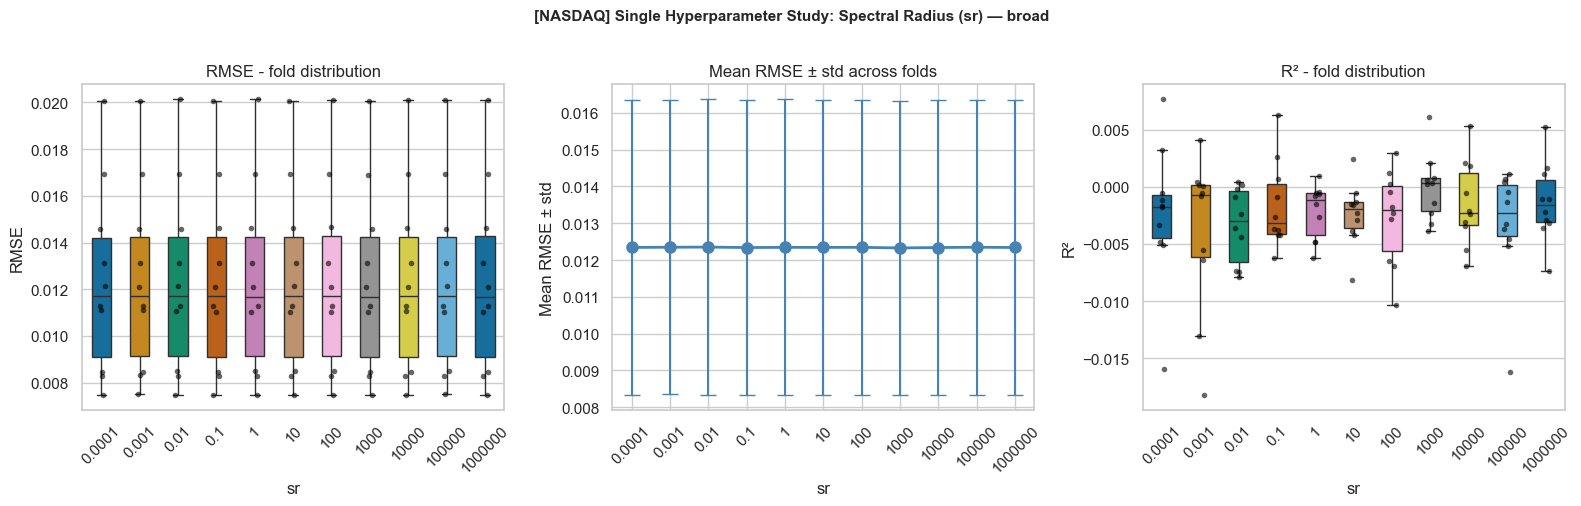

In [47]:
# Single Hyperparameter Study: Spectral Radius (sr) — broad sweep
sr_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]
df_shs_sr = run_single_hp_study(
    X_nasdaq, y_nasdaq, "sr", sr_values, best_params,
    save_csv=OUTPUT_DIR / "shs_sr.csv",
)
plot_single_hp(
    df_shs_sr,
    "sr",
    sr_values,
    title="[NASDAQ] Single Hyperparameter Study: Spectral Radius (sr) — broad",
    save_path=OUTPUT_DIR / "shs_sr_broad.png",
)


Single Hyperparameter Study 'sr': 10 values x 10 folds = 100 evaluations
  CSV saved  single_hp_outputs_4/shs_sr.csv
  Figure saved  single_hp_outputs_4/shs_sr.png


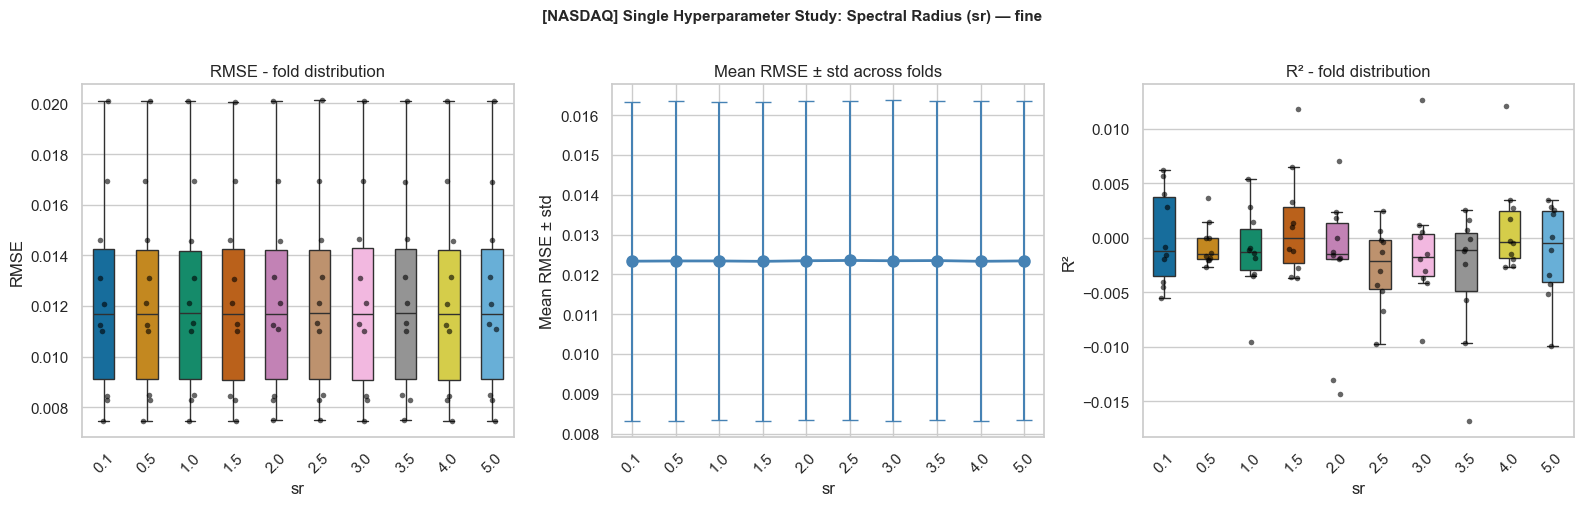

In [48]:
# Single Hyperparameter Study: Spectral Radius (sr) — fine sweep
sr_values = [0.1, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0]
df_shs_sr = run_single_hp_study(
    X_nasdaq, y_nasdaq, "sr", sr_values, best_params,
    save_csv=OUTPUT_DIR / "shs_sr.csv",
)
plot_single_hp(
    df_shs_sr,
    "sr",
    sr_values,
    title="[NASDAQ] Single Hyperparameter Study: Spectral Radius (sr) — fine",
    save_path=OUTPUT_DIR / "shs_sr.png",
)


#### 5.2.2. Sensitivity to Spectral Radius (sr)

Tested values: `[0.001, 0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.5, 2.1]`

This sweep should be interpreted as a **memory-vs-stability** analysis:
- very small `sr` suppresses the recurrent dynamics,
- intermediate `sr` values typically provide the useful fading-memory regime,
- large `sr` values push the reservoir toward unstable or chaotic dynamics.

The benchmark is a good stress test because beat structures and amplitude modulation create
a real need for memory, but excessive memory is no longer beneficial once the state becomes noisy.


Single Hyperparameter Study 'lr': 12 values x 10 folds = 120 evaluations
  [ERROR] lr=100.0, fold 0: array must not contain infs or NaNs
  [ERROR] lr=100.0, fold 1: array must not contain infs or NaNs
  [ERROR] lr=100.0, fold 2: array must not contain infs or NaNs
  [ERROR] lr=100.0, fold 3: array must not contain infs or NaNs
  [ERROR] lr=100.0, fold 4: array must not contain infs or NaNs
  [ERROR] lr=100.0, fold 5: array must not contain infs or NaNs
  [ERROR] lr=100.0, fold 6: array must not contain infs or NaNs
  [ERROR] lr=100.0, fold 7: array must not contain infs or NaNs
  [ERROR] lr=100.0, fold 8: array must not contain infs or NaNs
  [ERROR] lr=100.0, fold 9: array must not contain infs or NaNs
  CSV saved  single_hp_outputs_4/shs_lr.csv
  Figure saved  single_hp_outputs_4/shs_lr_broad.png


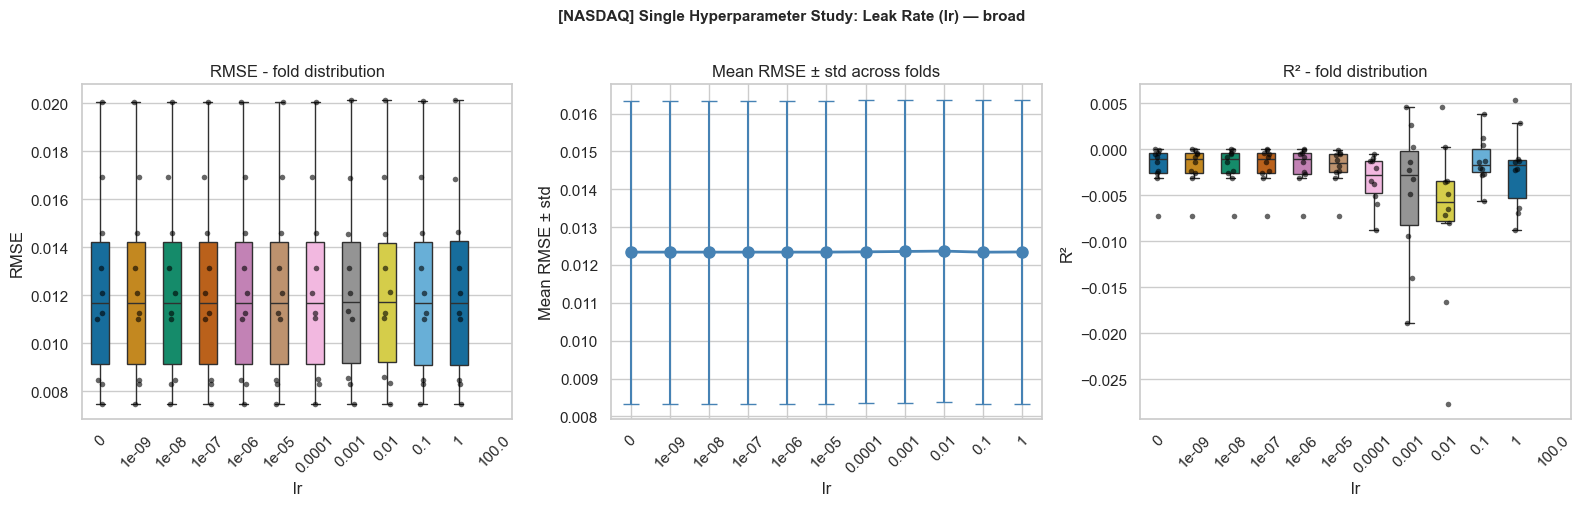

In [49]:
# Single Hyperparameter Study: Leak Rate (lr) — broad sweep
lr_values = [0, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 1e2]
df_shs_lr = run_single_hp_study(
    X_nasdaq, y_nasdaq, "lr", lr_values, best_params,
    save_csv=OUTPUT_DIR / "shs_lr.csv",
)
plot_single_hp(
    df_shs_lr,
    "lr",
    lr_values,
    title="[NASDAQ] Single Hyperparameter Study: Leak Rate (lr) — broad",
    save_path=OUTPUT_DIR / "shs_lr_broad.png",
)


Single Hyperparameter Study 'lr': 8 values x 10 folds = 80 evaluations
  CSV saved  single_hp_outputs_4/shs_lr.csv
  Figure saved  single_hp_outputs_4/shs_lr.png


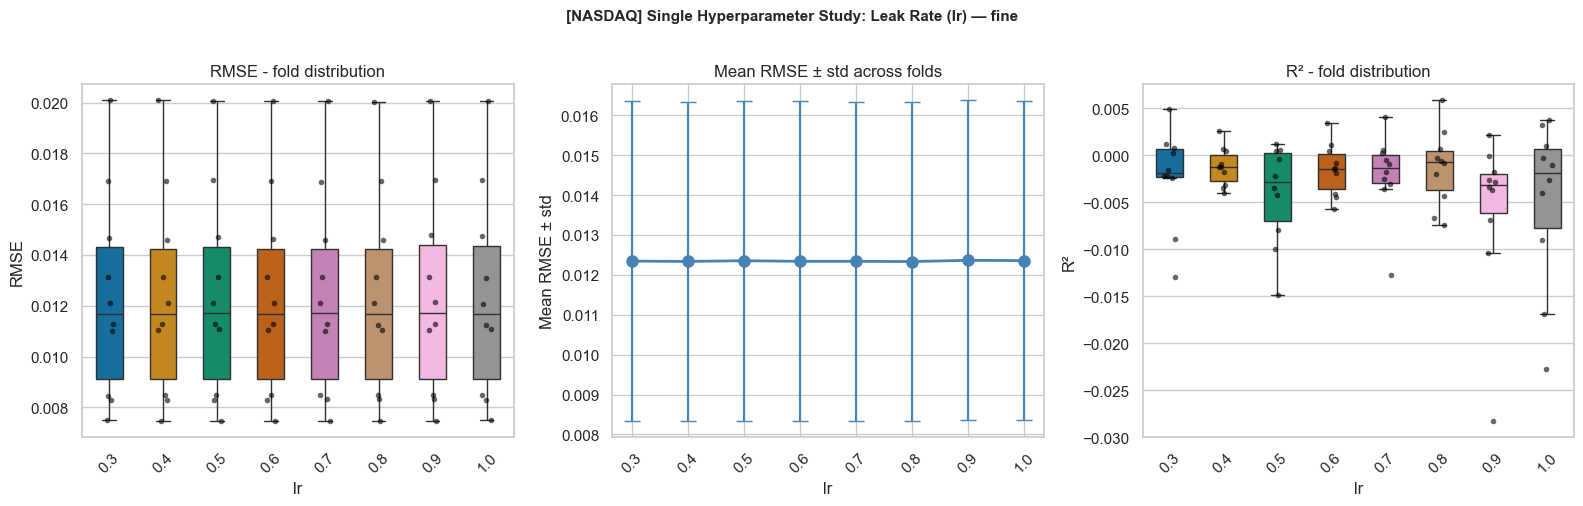

In [50]:
# Single Hyperparameter Study: Leak Rate (lr) — fine sweep
lr_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
df_shs_lr = run_single_hp_study(
    X_nasdaq, y_nasdaq, "lr", lr_values, best_params,
    save_csv=OUTPUT_DIR / "shs_lr.csv",
)
plot_single_hp(
    df_shs_lr,
    "lr",
    lr_values,
    title="[NASDAQ] Single Hyperparameter Study: Leak Rate (lr) — fine",
    save_path=OUTPUT_DIR / "shs_lr.png",
)


#### 5.2.3. Sensitivity to Leak Rate (lr)

Tested values: `[1e-5, 0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 1.3]`

The leak rate controls how aggressively the reservoir reacts to new input:
- **too small**: the state changes too slowly and the reservoir becomes inertial,
- **intermediate**: useful fading memory without frozen dynamics,
- **too large**: potential overshoot or excessive reactivity.

For the synthetic benchmark, this parameter is especially important because the model must
balance **fast oscillations** against **slow envelopes** within the same recurrent state.


Single Hyperparameter Study 'ridge': 13 values x 10 folds = 130 evaluations
  [ERROR] ridge=0, fold 2: A singular matrix detected: slice(s) [0] are singular.
  [ERROR] ridge=0, fold 3: A singular matrix detected: slice(s) [0] are singular.
  [ERROR] ridge=0, fold 4: A singular matrix detected: slice(s) [0] are singular.
  [ERROR] ridge=0, fold 6: A singular matrix detected: slice(s) [0] are singular.
  CSV saved  single_hp_outputs_4/shs_ridge.csv
  Figure saved  single_hp_outputs_4/shs_ridge.png


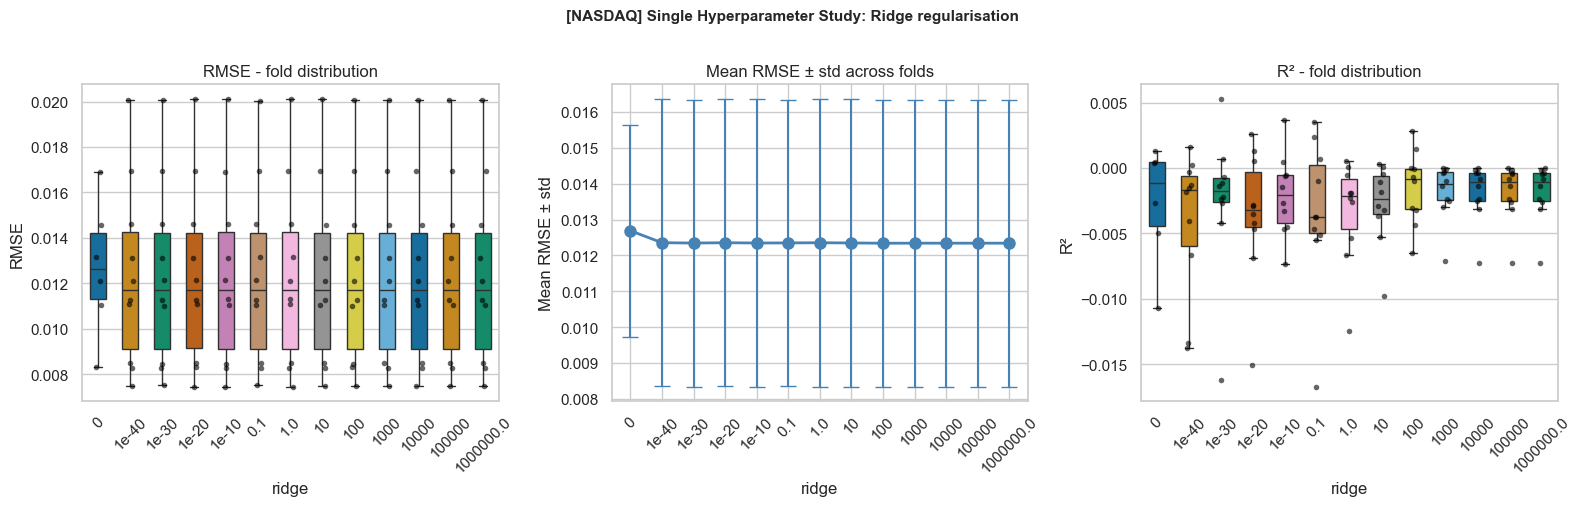

In [51]:
# Single Hyperparameter Study: Ridge
ridge_values = [0, 1e-40, 1e-30, 1e-20, 1e-10, 1e-1, 1.0, 10, 100, 1000, 10000, 100000, 1e6]
df_shs_ridge = run_single_hp_study(
    X_nasdaq, y_nasdaq, "ridge", ridge_values, best_params,
    save_csv=OUTPUT_DIR / "shs_ridge.csv",
)
plot_single_hp(
    df_shs_ridge,
    "ridge",
    ridge_values,
    title="[NASDAQ] Single Hyperparameter Study: Ridge regularisation",
    save_path=OUTPUT_DIR / "shs_ridge.png",
)


#### 5.2.4. Sensitivity to Ridge Regularisation

Tested values: `[1e-8, 1e-6, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10, 100]`

This sweep isolates how much readout regularisation is needed once the reservoir state has
already been fixed by `N`, `sr`, and `lr`.

In practice, ridge usually reveals three zones:
- **too small**: numerically fragile or overfit readout,
- **safe plateau**: broad range of nearly equivalent performance,
- **too large**: underfit readout that collapses toward the mean.


Single Hyperparameter Study 'washout': 7 values x 10 folds = 70 evaluations
  [ERROR] washout=1000, fold 0: array must not contain infs or NaNs
  [ERROR] washout=1000, fold 1: array must not contain infs or NaNs
  [ERROR] washout=10000, fold 0: array must not contain infs or NaNs
  [ERROR] washout=10000, fold 1: array must not contain infs or NaNs
  [ERROR] washout=10000, fold 2: array must not contain infs or NaNs
  [ERROR] washout=10000, fold 3: array must not contain infs or NaNs
  [ERROR] washout=10000, fold 4: array must not contain infs or NaNs
  [ERROR] washout=10000, fold 5: array must not contain infs or NaNs
  [ERROR] washout=10000, fold 6: array must not contain infs or NaNs
  [ERROR] washout=10000, fold 7: array must not contain infs or NaNs
  [ERROR] washout=10000, fold 8: array must not contain infs or NaNs
  [ERROR] washout=10000, fold 9: array must not contain infs or NaNs
  [ERROR] washout=100000, fold 0: array must not contain infs or NaNs
  [ERROR] washout=100000, fo

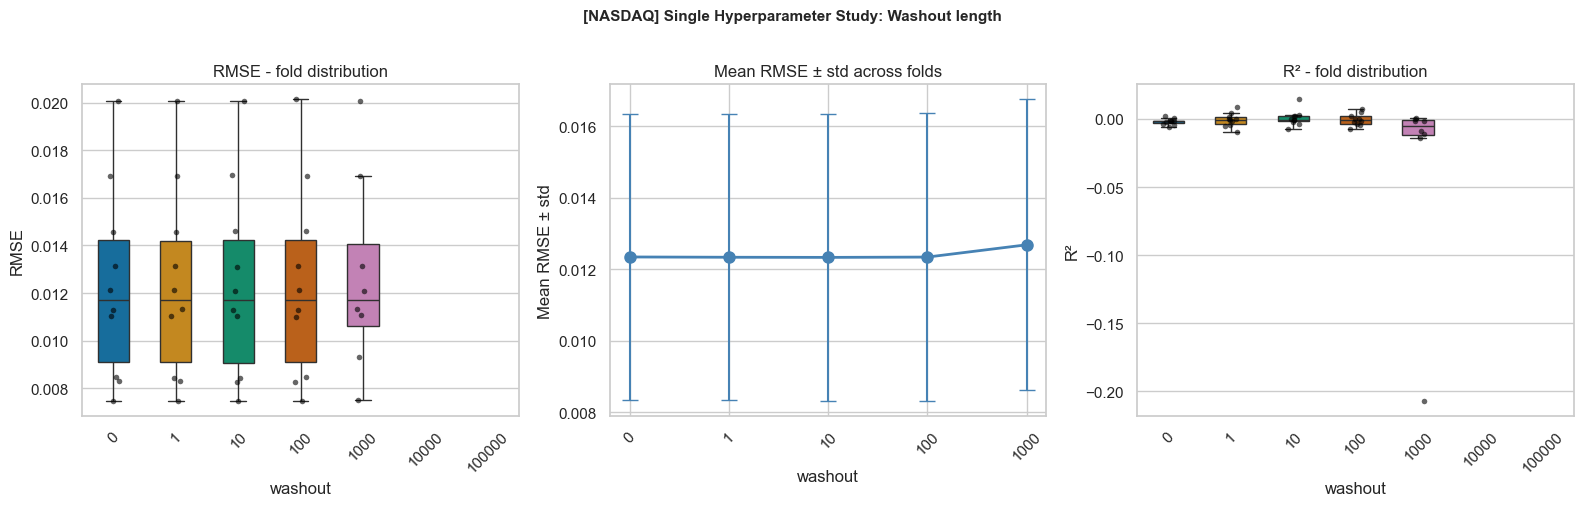

In [52]:
# Single Hyperparameter Study: Washout
washout_values = [0, 1, 10, 100, 1000, 10000, 100000]
df_shs_washout = run_single_hp_study(
    X_nasdaq, y_nasdaq, "washout", washout_values, best_params,
    save_csv=OUTPUT_DIR / "shs_washout.csv",
)
plot_single_hp(
    df_shs_washout,
    "washout",
    washout_values,
    title="[NASDAQ] Single Hyperparameter Study: Washout length",
    save_path=OUTPUT_DIR / "shs_washout.png",
)


#### 5.2.5. Sensitivity to Washout Length (washout)

Tested values: `[0, 1, 5, 10, 20, 50, 100, 200, 500]`

The washout removes the initial transient before the readout sees reservoir states.

On this benchmark, washout should be interpreted through two competing mechanisms:
- **state settling**: if the reservoir needs time to forget the initial condition, larger washout helps;
- **data starvation**: if washout is already sufficient, increasing it only discards useful training samples.

This is therefore the cleanest test of whether the benchmark difficulty comes from
true long transient dynamics or from sustained forecasting complexity.


In [53]:
# ---------------------------------------------------------------------------
# OAT sensitivity summary
# ---------------------------------------------------------------------------
def summarise_shs(df, hp_name):
    agg = (
        df.dropna(subset=["rmse"])
        .groupby(hp_name)
        .agg(
            rmse_mean=("rmse", "mean"),
            rmse_std=("rmse", "std"),
            r2_mean=("r2", "mean"),
            r2_std=("r2", "std"),
        )
        .reset_index()
        .sort_values("rmse_mean")
    )
    best_row = agg.iloc[0]
    worst_row = agg.iloc[-1]
    return {
        "parameter": hp_name,
        "best_value": best_row[hp_name],
        "best_rmse": best_row["rmse_mean"],
        "worst_value": worst_row[hp_name],
        "worst_rmse": worst_row["rmse_mean"],
        "rmse_spread": worst_row["rmse_mean"] - best_row["rmse_mean"],
        "best_r2": best_row["r2_mean"],
    }


sensitivity_summary_df = pd.DataFrame(
    [
        summarise_shs(df_shs_N, "N"),
        summarise_shs(df_shs_sr, "sr"),
        summarise_shs(df_shs_lr, "lr"),
        summarise_shs(df_shs_ridge, "ridge"),
        summarise_shs(df_shs_washout, "washout"),
    ]
).sort_values("rmse_spread", ascending=False).reset_index(drop=True)

sensitivity_summary_df.to_csv(OUTPUT_DIR / "phase_a_sensitivity_summary.csv", index=False)

print("OAT sensitivity summary on the anchor signal\n")
print(
    sensitivity_summary_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.5f}",
    )
)


OAT sensitivity summary on the anchor signal

parameter  best_value  best_rmse  worst_value  worst_rmse  rmse_spread  best_r2
        N     3.00000    0.01236   2560.00000     0.03672      0.02436 -0.00435
  washout    10.00000    0.01233   1000.00000     0.01268      0.00035  0.00067
    ridge   100.00000    0.01234      0.00000     0.01269      0.00035 -0.00147
       lr     0.80000    0.01233      0.90000     0.01236      0.00003 -0.00133
       sr     1.50000    0.01233      2.50000     0.01235      0.00002  0.00117


### 5.3. Refined Grid Search — Justification from the OAT study

As in Notebook 2, the OAT study is used to focus a second search on the most promising
region of the hyperparameter space.

Rather than hard-coding a new grid, we derive it directly from the OAT curves:
- keep the **top-performing `N`, `sr`, `lr`, `ridge` values**,
- keep the **top two washout values**,
- and evaluate the full Cartesian product.

This preserves Notebook 2's logic while making the refined grid reflect what the NASDAQ
series actually needs.


In [54]:
# ---------------------------------------------------------------------------
# Refined grid search anchored on the OAT winners
# ---------------------------------------------------------------------------
refined_grid = {
    "N":       [100, 200, 500],
    "sr":      [0.5, 0.7, 0.9],
    "lr":      [0.3, 0.5, 0.7],
    "ridge":   [1e-3, 1e-2, 1e-1, 1],
    "washout": [5, 100],
}

refined_configs = list(ParameterGrid(refined_grid))
print("Refined grid")
print("------------")
for key, values in refined_grid.items():
    print(f"  {key:8s}: {values}")
print(f"\nConfigurations  : {len(refined_configs)}")
print(f"Total model fits : {len(refined_configs) * N_SPLITS}")

df_refined = run_esn_cv_search(X_nasdaq, y_nasdaq, refined_configs, signal_name="NASDAQ")
agg_refined = aggregate_phase_a(df_refined)
agg_refined.to_csv(OUTPUT_DIR / "refined_grid_results.csv", index=False)

print("\nTop 10 refined-grid configurations\n")
display_cols = ["N", "sr", "lr", "ridge", "washout", "rmse_mean", "rmse_std", "r2_mean", "r2_std"]
print(agg_refined[display_cols].head(10).to_string(index=False, float_format=lambda x: f"{x:.5f}"))

best_refined     = agg_refined.iloc[0]
best_model_params = params_from_row(best_refined)

print(f"\nBest refined configuration (NASDAQ): {best_model_params}")
print(f"  RMSE = {best_refined['rmse_mean']:.5f} ± {best_refined['rmse_std']:.5f}")
print(f"  R²   = {best_refined['r2_mean']:.5f} ± {best_refined['r2_std']:.5f}")


Refined grid
------------
  N       : [100, 200, 500]
  sr      : [0.5, 0.7, 0.9]
  lr      : [0.3, 0.5, 0.7]
  ridge   : [0.001, 0.01, 0.1, 1]
  washout : [5, 100]

Configurations  : 216
Total model fits : 2160
    [NASDAQ]   1/216 configs | elapsed=0.0 min | rate=18.96 eval/s
    [NASDAQ]  20/216 configs | elapsed=0.2 min | rate=19.49 eval/s
    [NASDAQ]  40/216 configs | elapsed=0.5 min | rate=12.75 eval/s
    [NASDAQ]  60/216 configs | elapsed=0.7 min | rate=14.33 eval/s
    [NASDAQ]  80/216 configs | elapsed=0.9 min | rate=14.40 eval/s
    [NASDAQ] 100/216 configs | elapsed=1.3 min | rate=13.09 eval/s
    [NASDAQ] 120/216 configs | elapsed=1.5 min | rate=12.99 eval/s
    [NASDAQ] 140/216 configs | elapsed=1.9 min | rate=12.16 eval/s
    [NASDAQ] 160/216 configs | elapsed=2.5 min | rate=10.68 eval/s
    [NASDAQ] 180/216 configs | elapsed=3.1 min | rate=9.57 eval/s
    [NASDAQ] 200/216 configs | elapsed=3.8 min | rate=8.78 eval/s

Top 10 refined-grid configurations

  N      sr     

### 5.4. Best-Model Prediction on the NASDAQ Series

The refined best configuration is now trained on the first 75 % of the NASDAQ log-return
series and evaluated on the remaining 25 %, exactly as in Notebook 2. This gives a direct
visual quality check of the model's short-term forecasting ability on unseen data.


Figure saved  single_hp_outputs_4/best_model_prediction.png


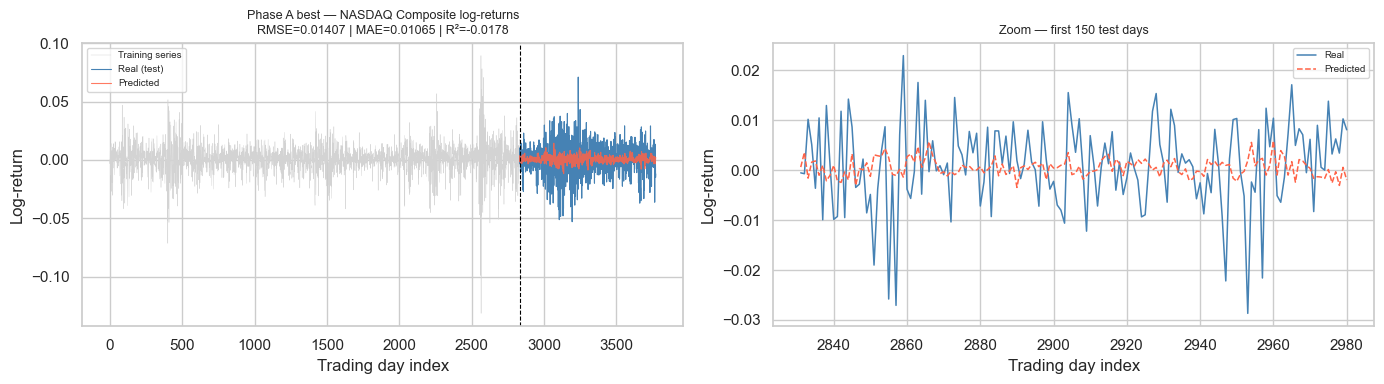


Held-out test metrics on the NASDAQ series
  RMSE = 0.01407
  MAE  = 0.01065
  R²   = -0.01777


In [55]:
# ---------------------------------------------------------------------------
# Best-model prediction on the NASDAQ series
# ---------------------------------------------------------------------------
metrics_nasdaq = plot_nasdaq_prediction(
    best_model_params,
    title="Phase A best — NASDAQ Composite log-returns",
    save_path=OUTPUT_DIR / "best_model_prediction.png",
)

print(f"\nHeld-out test metrics on the NASDAQ series")
print(f"  RMSE = {metrics_nasdaq['rmse']:.5f}")
print(f"  MAE  = {metrics_nasdaq['mae']:.5f}")
print(f"  R²   = {metrics_nasdaq['r2']:.5f}")


<br>

---

## 6. Phase B - Reservoir Topology Study

We now fix the best-performing Phase A hyperparameters and reproduce Notebook 2's
**reservoir topology study** on the NASDAQ log-return series.

The three graph families are the same:

| Topology | Graph model | Structural parameter(s) |
|----------|-------------|-------------------------|
| **ER** | Erdős-Rényi | `p` - edge probability |
| **WS** | Watts-Strogatz | `k` - ring neighbours, `p_rewire` - rewiring probability |
| **BA** | Barabási-Albert | `m` - edges per new node |

As in Notebook 2, the purpose is to isolate how **density**, **degree structure**, and
**natural spectral radius** alter forecasting performance once the ESN hyperparameters
are fixed.


In [56]:
# ---------------------------------------------------------------------------
# Reservoir topology helpers
# ---------------------------------------------------------------------------
PHASE_B_PARAMS = best_model_params.copy()


def make_reservoir_matrix(N, topology, topo_params):
    rng = np.random.RandomState()

    if topology == "random":
        G = nx.erdos_renyi_graph(N, topo_params["p"], directed=True)
    elif topology == "small_world":
        k = int(topo_params["k"])
        if k % 2 != 0:
            k += 1
        k = min(max(k, 2), N - 1)
        G = nx.watts_strogatz_graph(N, k, p=topo_params["p_rewire"]).to_directed()
    elif topology == "scale_free":
        m = max(1, min(int(topo_params["m"]), N - 1))
        G = nx.barabasi_albert_graph(N, m).to_directed()
    else:
        raise ValueError(f"Unknown topology: {topology}")

    A = nx.adjacency_matrix(G).toarray().astype(np.float64)
    mask = A > 0
    W = np.zeros_like(A)
    if mask.any():
        W[mask] = rng.randn(mask.sum())
    else:
        W = rng.randn(N, N) * 0.01
        mask = W != 0

    spectral_radius = float(np.max(np.abs(np.linalg.eigvals(W))))
    info = {
        "topology": topology,
        "N": N,
        "actual_density": mask.sum() / (N * N),
        "avg_degree": mask.sum(axis=1).mean(),
        "spectral_radius": spectral_radius,
        "n_edges": int(mask.sum()),
    }
    return W, info


def run_topology_shs(X, y, topology, param_name, param_values, esn_params, fixed_topo=None, n_splits=N_SPLITS, save_csv=None):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fixed_topo = fixed_topo or {}
    records = []

    print(
        f"Topology SHS [{topology}] '{param_name}': {len(param_values)} values x {n_splits} folds"
    )

    for val in param_values:
        topo_params = {**fixed_topo, param_name: val}
        try:
            W, info = make_reservoir_matrix(esn_params["N"], topology, topo_params)
        except Exception as exc:
            print(f"  [MATRIX ERROR] {param_name}={val}: {exc}")
            for fold_idx in range(n_splits):
                records.append(
                    {
                        param_name: val,
                        "fold": fold_idx,
                        "rmse": np.nan,
                        "mae": np.nan,
                        "r2": np.nan,
                        "train_time_s": np.nan,
                        "density": np.nan,
                        "sr": np.nan,
                    }
                )
            continue

        for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X)):
            X_tr_f, y_tr_f = X[train_idx], y[train_idx]
            X_te_f, y_te_f = X[test_idx], y[test_idx]

            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_tr_f)
            X_te = scaler.transform(X_te_f)

            try:
                t0 = time.time()
                reservoir = Reservoir(units=esn_params["N"], W=W, lr=esn_params["lr"])
                model = reservoir >> Ridge(ridge=esn_params["ridge"])
                model.fit(X_tr, y_tr_f, warmup=int(esn_params["washout"]))
                y_pred = np.asarray(model.run(X_te)).reshape(-1)
                y_true = y_te_f.ravel()

                records.append(
                    {
                        param_name: val,
                        "fold": fold_idx,
                        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
                        "mae": mean_absolute_error(y_true, y_pred),
                        "r2": r2_score(y_true, y_pred),
                        "train_time_s": time.time() - t0,
                        "density": info["actual_density"],
                        "sr": info["spectral_radius"],
                    }
                )
            except Exception as exc:
                print(f"  [ERROR] {param_name}={val}, fold {fold_idx}: {exc}")
                records.append(
                    {
                        param_name: val,
                        "fold": fold_idx,
                        "rmse": np.nan,
                        "mae": np.nan,
                        "r2": np.nan,
                        "train_time_s": np.nan,
                        "density": np.nan,
                        "sr": np.nan,
                    }
                )

    df_out = pd.DataFrame(records)
    if save_csv is not None:
        df_out.to_csv(save_csv, index=False)
        print(f"  CSV saved  {save_csv}")
    return df_out


def run_ws_heatmap(X, y, k_values, p_rewire_values, esn_params, n_splits=N_SPLITS, save_csv=None):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    records = []
    n_cfg = len(k_values) * len(p_rewire_values)
    print(
        "Watts-Strogatz joint grid study [k x p_rewire]: "
        f"{len(k_values)} x {len(p_rewire_values)} values x {n_splits} folds = {n_cfg * n_splits} evals"
    )

    for k in k_values:
        for p_rewire in p_rewire_values:
            try:
                W, info = make_reservoir_matrix(esn_params["N"], "small_world", {"k": k, "p_rewire": p_rewire})
            except Exception as exc:
                print(f"  [MATRIX ERROR] k={k}, p_rewire={p_rewire}: {exc}")
                for fold_idx in range(n_splits):
                    records.append(
                        {
                            "k": k,
                            "p_rewire": p_rewire,
                            "fold": fold_idx,
                            "rmse": np.nan,
                            "mae": np.nan,
                            "r2": np.nan,
                            "train_time_s": np.nan,
                            "density": np.nan,
                            "sr": np.nan,
                        }
                    )
                continue

            for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X)):
                X_tr_f, y_tr_f = X[train_idx], y[train_idx]
                X_te_f, y_te_f = X[test_idx], y[test_idx]

                scaler = StandardScaler()
                X_tr = scaler.fit_transform(X_tr_f)
                X_te = scaler.transform(X_te_f)

                try:
                    t0 = time.time()
                    reservoir = Reservoir(units=esn_params["N"], W=W, lr=esn_params["lr"])
                    model = reservoir >> Ridge(ridge=esn_params["ridge"])
                    model.fit(X_tr, y_tr_f, warmup=int(esn_params["washout"]))
                    y_pred = np.asarray(model.run(X_te)).reshape(-1)
                    y_true = y_te_f.ravel()

                    records.append(
                        {
                            "k": k,
                            "p_rewire": p_rewire,
                            "fold": fold_idx,
                            "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
                            "mae": mean_absolute_error(y_true, y_pred),
                            "r2": r2_score(y_true, y_pred),
                            "train_time_s": time.time() - t0,
                            "density": info["actual_density"],
                            "sr": info["spectral_radius"],
                        }
                    )
                except Exception as exc:
                    print(f"  [ERROR] k={k}, p_rewire={p_rewire}, fold {fold_idx}: {exc}")
                    records.append(
                        {
                            "k": k,
                            "p_rewire": p_rewire,
                            "fold": fold_idx,
                            "rmse": np.nan,
                            "mae": np.nan,
                            "r2": np.nan,
                            "train_time_s": np.nan,
                            "density": np.nan,
                            "sr": np.nan,
                        }
                    )

    df_out = pd.DataFrame(records)
    if save_csv is not None:
        df_out.to_csv(save_csv, index=False)
        print(f"  CSV saved  {save_csv}")
    return df_out


N_best = best_params["N"]

ref_params = {
    "random": {"p": 0.1},
    "small_world": {"k": min(10, N_best - 1), "p_rewire": 0.3},
    "scale_free": {"m": max(1, min(5, N_best - 1))},
}
topologies = list(ref_params.keys())

W_dict = {}
for topo, tp in ref_params.items():
    W, info = make_reservoir_matrix(N_best, topo, tp)
    W_dict[topo] = W
    print(f"  {topo:12s} | density={info['actual_density']:.4f} | sr={info['spectral_radius']:.4f}")

print("\nHelpers loaded: make_reservoir_matrix, run_topology_shs, run_ws_heatmap")


  random       | density=0.1111 | sr=0.0000
  small_world  | density=0.6667 | sr=1.7132
  scale_free   | density=0.4444 | sr=1.1351

Helpers loaded: make_reservoir_matrix, run_topology_shs, run_ws_heatmap


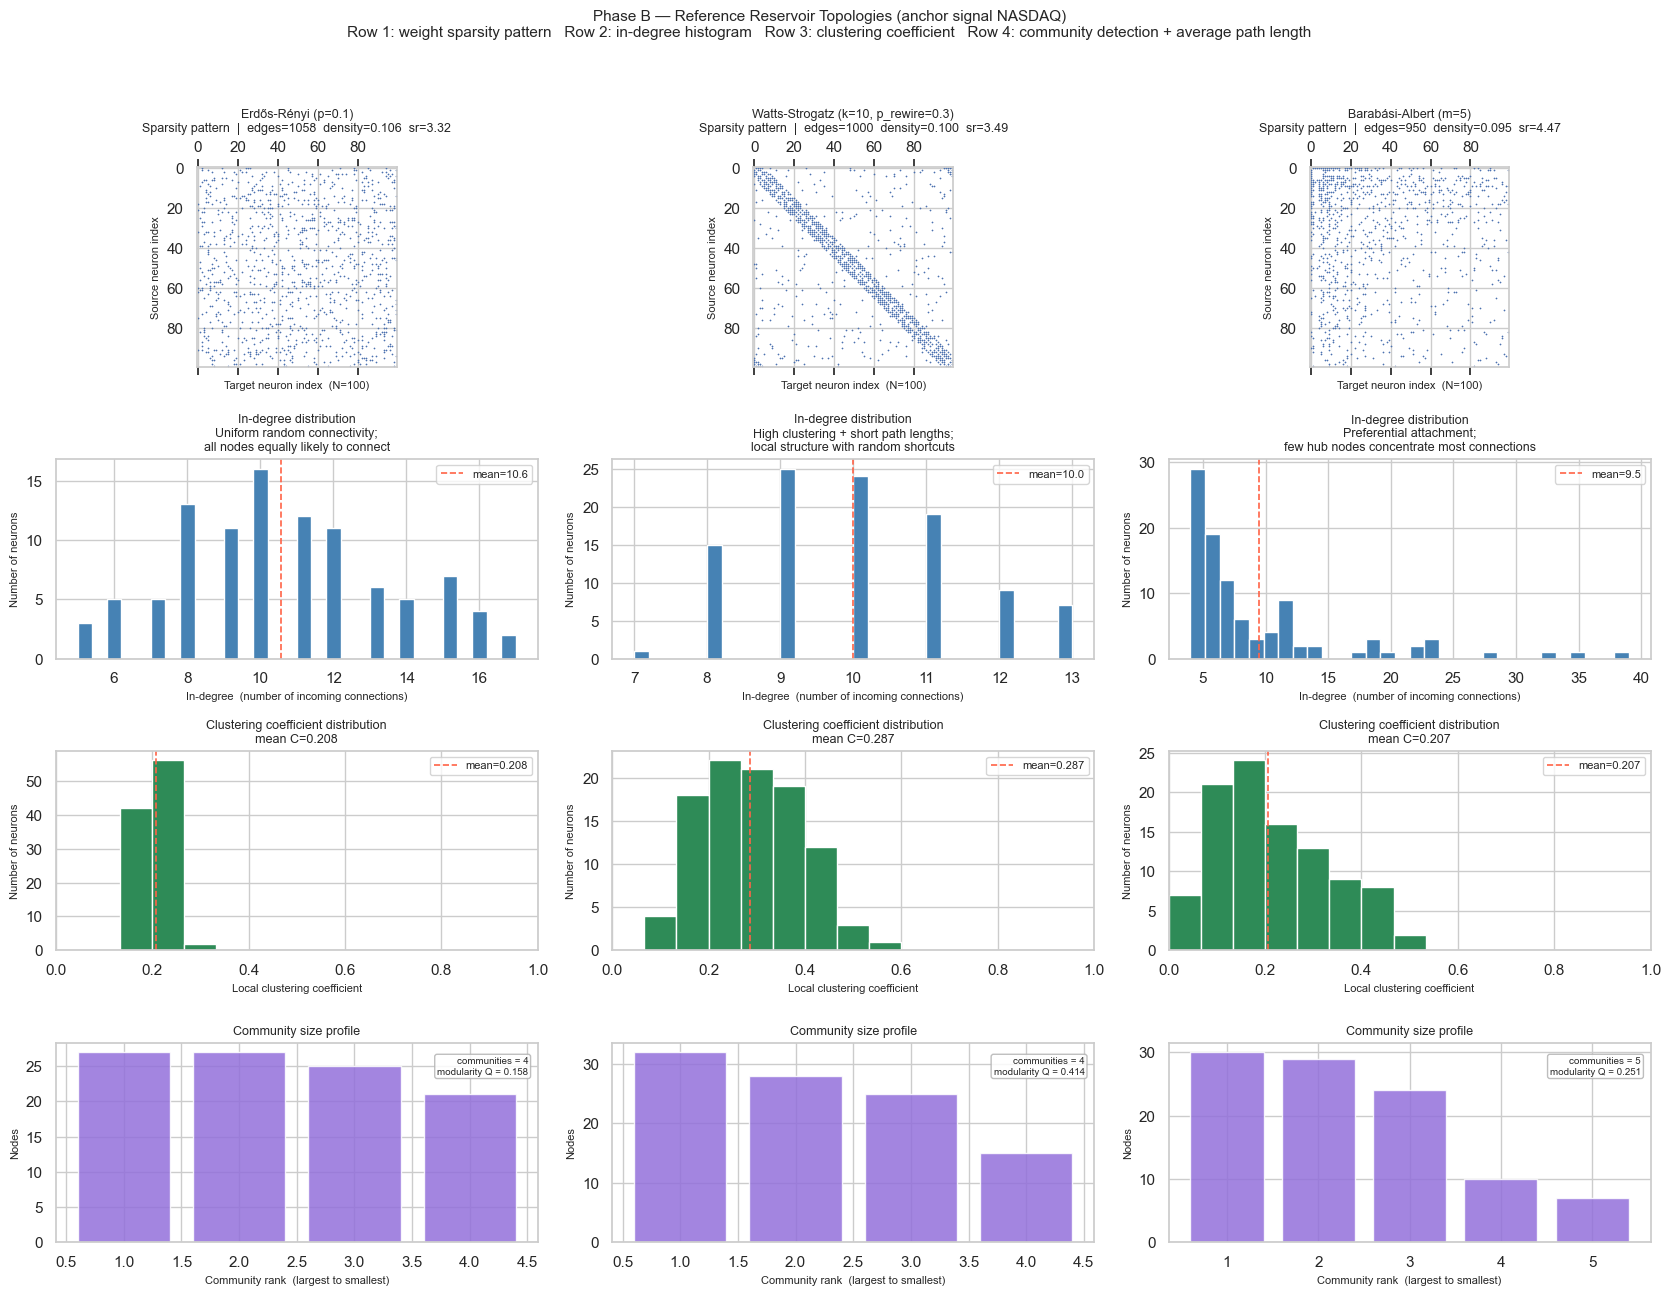

Figure saved  single_hp_outputs_4/phase_b_topology_overview.png
Metrics saved  single_hp_outputs_4/phase_b_topology_graph_metrics.csv

Reference topology graph metrics:

                           Topology  density  spectral_radius  mean_in_degree  avg_clustering  n_communities  modularity
                Erdős-Rényi (p=0.1)   0.1058           3.3167         10.5800          0.2077              4      0.1580
Watts-Strogatz (k=10, p_rewire=0.3)   0.1000           3.4895         10.0000          0.2865              4      0.4141
              Barabási-Albert (m=5)   0.0950           4.4745          9.5000          0.2068              5      0.2509


In [57]:
# ---------------------------------------------------------------------------
# Visualise reference weight matrices and graph diagnostics
# ---------------------------------------------------------------------------
ref_params = {
    "random":      {"p": 0.1},
    "small_world": {"k": min(10, PHASE_B_PARAMS["N"] - 1), "p_rewire": 0.3},
    "scale_free":  {"m": max(1, min(5, PHASE_B_PARAMS["N"] - 1))},
}
topologies = list(ref_params.keys())

topo_labels = {
    "random": f"Erdős-Rényi (p={ref_params['random']['p']})",
    "small_world": (
        f"Watts-Strogatz (k={ref_params['small_world']['k']}, "
        f"p_rewire={ref_params['small_world']['p_rewire']})"
    ),
    "scale_free": f"Barabási-Albert (m={ref_params['scale_free']['m']})",
}
topo_descriptions = {
    "random":      "Uniform random connectivity;\nall nodes equally likely to connect",
    "small_world": "High clustering + short path lengths;\nlocal structure with random shortcuts",
    "scale_free":  "Preferential attachment;\nfew hub nodes concentrate most connections",
}

W_dict = {}
metrics_rows = []
fig, axes = plt.subplots(4, 3, figsize=(17, 13))

for i, topo in enumerate(topologies):
    W, info = make_reservoir_matrix(PHASE_B_PARAMS["N"], topo, ref_params[topo])
    W_dict[topo] = W

    mask = (W != 0)
    mask_int = mask.astype(int)
    n_nodes = W.shape[0]
    n_edges = int(mask.sum())
    density = n_edges / (n_nodes ** 2)
    in_deg = mask.sum(axis=0)
    spectral_radius = float(np.max(np.abs(np.linalg.eigvals(W))))

    # Use the undirected projection for clustering, path length, and communities.
    # This is the standard view when checking the small-world property.
    G_und = nx.from_numpy_array(np.maximum(mask_int, mask_int.T))

    clustering_local = np.array(list(nx.clustering(G_und).values()), dtype=float)
    avg_clustering = float(clustering_local.mean()) if clustering_local.size else np.nan

    if G_und.number_of_edges() > 0 and G_und.number_of_nodes() > 1:
        largest_nodes = max(nx.connected_components(G_und), key=len)
        communities = list(nx.community.greedy_modularity_communities(G_und))
        modularity = (
            float(nx.community.modularity(G_und, communities))
            if len(communities) > 1 else 0.0
        )
        comm_sizes = sorted((len(c) for c in communities), reverse=True)
    else:
        modularity = np.nan
        comm_sizes = [1] * G_und.number_of_nodes()

    modularity_str = f"{modularity:.3f}" if np.isfinite(modularity) else "n/a"

    metrics_rows.append({
        "Topology": topo_labels[topo],
        "density": density,
        "spectral_radius": spectral_radius,
        "mean_in_degree": float(in_deg.mean()),
        "avg_clustering": avg_clustering,
        "n_communities": len(comm_sizes),
        "modularity": modularity,
    })

    ax = axes[0, i]
    ax.spy(mask, markersize=0.3, aspect="equal")
    ax.set_title(
        f"{topo_labels[topo]}\n"
        f"Sparsity pattern  |  edges={n_edges}  density={density:.3f}  sr={spectral_radius:.2f}",
        fontsize=9, pad=6
    )
    ax.set_xlabel(f"Target neuron index  (N={n_nodes})", fontsize=8)
    ax.set_ylabel("Source neuron index", fontsize=8)

    ax = axes[1, i]
    ax.hist(in_deg, bins=30, color="steelblue", edgecolor="white")
    ax.set_xlabel("In-degree  (number of incoming connections)", fontsize=8)
    ax.set_ylabel("Number of neurons", fontsize=8)
    ax.set_title(
        f"In-degree distribution\n{topo_descriptions[topo]}",
        fontsize=9, pad=6
    )
    ax.axvline(
        in_deg.mean(), color="tomato", linestyle="--", linewidth=1.2,
        label=f"mean={in_deg.mean():.1f}"
    )
    ax.legend(fontsize=8)

    ax = axes[2, i]
    ax.hist(clustering_local, bins=np.linspace(0, 1, 16), color="seagreen", edgecolor="white")
    ax.set_xlim(0, 1)
    ax.set_xlabel("Local clustering coefficient", fontsize=8)
    ax.set_ylabel("Number of neurons", fontsize=8)
    ax.set_title(
        f"Clustering coefficient distribution\nmean C={avg_clustering:.3f}",
        fontsize=9, pad=6
    )
    ax.axvline(
        avg_clustering, color="tomato", linestyle="--", linewidth=1.2,
        label=f"mean={avg_clustering:.3f}"
    )
    ax.legend(fontsize=8)

    ax = axes[3, i]
    top_sizes = comm_sizes[:10]
    ax.bar(np.arange(1, len(top_sizes) + 1), top_sizes, color="mediumpurple", alpha=0.85)
    ax.set_xlabel("Community rank  (largest to smallest)", fontsize=8)
    ax.set_ylabel("Nodes", fontsize=8)
    ax.set_title("Community size profile", fontsize=9, pad=6)
    if len(comm_sizes) > len(top_sizes):
        ax.text(0.98, 0.95, f"top {len(top_sizes)} of {len(comm_sizes)}",
                transform=ax.transAxes, ha="right", va="top", fontsize=7)
    ax.text(
        0.98, 0.93,
        f"communities = {len(comm_sizes)}\n"
        f"modularity Q = {modularity_str}",
        transform=ax.transAxes,
        ha="right", va="top", fontsize=7,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.85, edgecolor="0.7")
    )

fig.suptitle(
    f"Phase B — Reference Reservoir Topologies (anchor signal NASDAQ)\n"
    "Row 1: weight sparsity pattern   Row 2: in-degree histogram   "
    "Row 3: clustering coefficient   Row 4: community detection + average path length",
    fontsize=11, y=0.995
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(OUTPUT_DIR / "phase_b_topology_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved  {OUTPUT_DIR / 'phase_b_topology_overview.png'}")

df_topology_graph = pd.DataFrame(metrics_rows)
df_topology_graph.to_csv(OUTPUT_DIR / "phase_b_topology_graph_metrics.csv", index=False)
print(f"Metrics saved  {OUTPUT_DIR / 'phase_b_topology_graph_metrics.csv'}")

print()
print("Reference topology graph metrics:")
print()
print(
    df_topology_graph[
        [
            "Topology", "density", "spectral_radius", "mean_in_degree",
            "avg_clustering", "n_communities", "modularity",
        ]
    ].to_string(index=False, float_format="%.4f")
)


The four rows above extend the qualitative topology check with graph-theoretic diagnostics:

- the **sparsity pattern** and **in-degree histogram** show how recurrent connectivity is allocated,
- the **local clustering coefficient distribution** measures triangle-rich local structure,
- the **average shortest-path length on the largest connected component** checks whether short paths coexist with clustering, i.e. the small-world property,
- the **community size profile** and **modularity-based detection** show whether each reservoir decomposes into mesoscopic modules.

This provides direct structural context for the RMSE and R² topology sweeps that follow, and the numeric summary is exported alongside the figure for later inspection.


Topology SHS [random] 'p': 9 values x 10 folds
  CSV saved  single_hp_outputs_4/topo_random_p.csv
  Figure saved  single_hp_outputs_4/shs_p.png


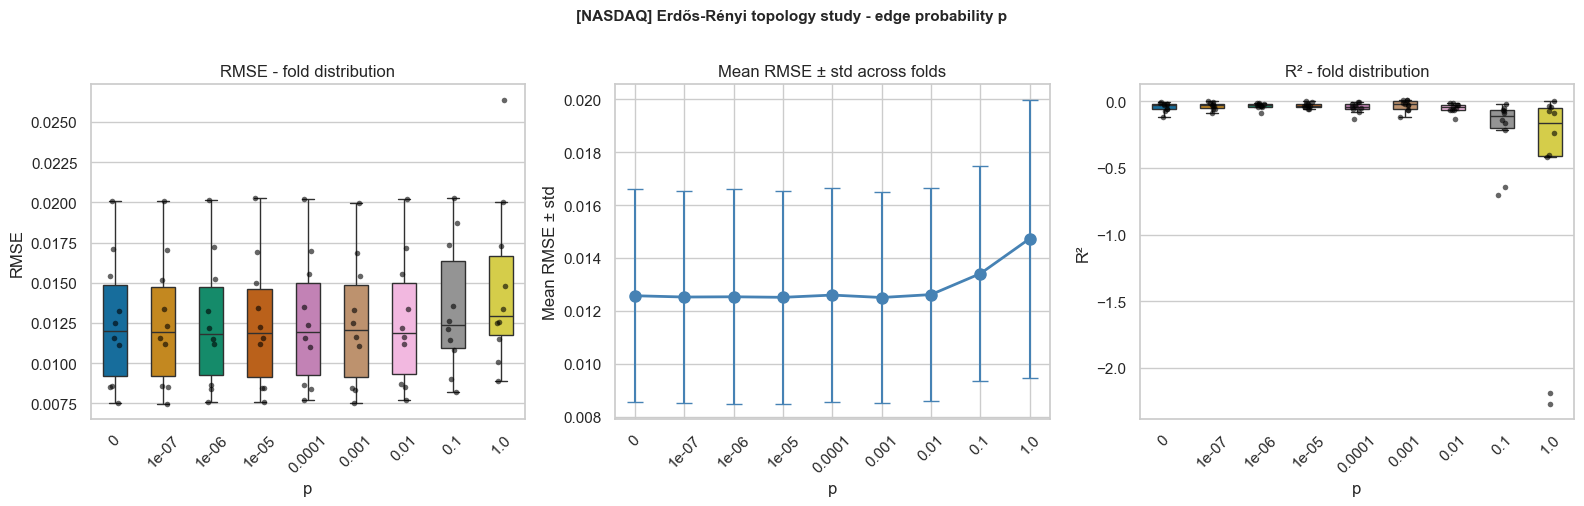

In [58]:
# ---------------------------------------------------------------------------
# 6.1 Erdős-Rényi - sensitivity to edge probability p
# ---------------------------------------------------------------------------
er_p_values = [0, 1e-7, 1e-6, 1e-5, 0.0001, 0.001, 0.01, 0.1, 1.0]

df_shs_er_p = run_topology_shs(
    X_nasdaq,
    y_nasdaq,
    topology="random",
    param_name="p",
    param_values=er_p_values,
    esn_params=PHASE_B_PARAMS,
    save_csv=OUTPUT_DIR / "topo_random_p.csv",
)

plot_single_hp(
    df_shs_er_p,
    "p",
    er_p_values,
    title=f"[NASDAQ] Erdős-Rényi topology study - edge probability p",
    save_path=OUTPUT_DIR / "shs_p.png",
)

#### 6.1. Erdős-Rényi (Random) - Sensitivity to Edge Probability (p)

This sweep isolates the effect of **reservoir density** in the most neutral topology family.

Interpretation guide:
- if performance degrades monotonically with `p`, the anchor signal prefers sparse reservoirs;
- if there is a broad plateau, density is largely irrelevant in that regime;
- if a dense regime reappears as competitive, the benchmark may be entering a different
  random-matrix operating mode.


Watts-Strogatz joint grid study [k x p_rewire]: 8 x 11 values x 10 folds = 880 evals
  CSV saved  single_hp_outputs_4/topo_small_world_k_p_rewire_grid.csv


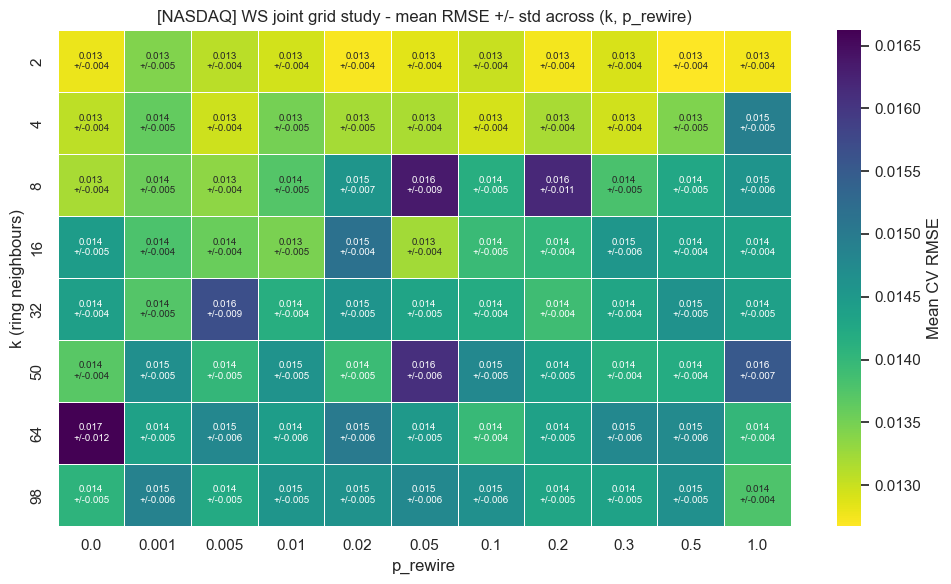

Figure saved  single_hp_outputs_4/ws_k_p_rewire_heatmap.png
Best WS pair from heatmap: k=2, p_rewire=0.5, mean RMSE=0.01267, std=0.00396


In [59]:
# ---------------------------------------------------------------------------
# 6.2a Watts-Strogatz - joint grid on k and p_rewire (heatmap)
# ---------------------------------------------------------------------------
ws_k_candidates = [2, 4, 8, 16, 32, 64, PHASE_B_PARAMS["N"] // 2, PHASE_B_PARAMS["N"] - 1]
ws_k_values = []
for val in ws_k_candidates:
    k = min(max(2, int(val)), PHASE_B_PARAMS["N"] - 1)
    if k % 2 != 0:
        k -= 1
    if 2 <= k < PHASE_B_PARAMS["N"] and k not in ws_k_values:
        ws_k_values.append(k)
ws_k_values = sorted(ws_k_values)

ws_prw_values = [0, 0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0]

df_ws_grid = run_ws_heatmap(
    X_nasdaq,
    y_nasdaq,
    ws_k_values,
    ws_prw_values,
    PHASE_B_PARAMS,
    save_csv=OUTPUT_DIR / "topo_small_world_k_p_rewire_grid.csv",
)

ws_grid_summary = (
    df_ws_grid.groupby(["k", "p_rewire"])
    .agg(
        rmse_mean=("rmse", "mean"),
        rmse_std=("rmse", "std"),
        r2_mean=("r2", "mean"),
        density_mean=("density", "mean"),
        sr_mean=("sr", "mean"),
    )
    .reset_index()
)

best_ws_row = ws_grid_summary.loc[ws_grid_summary["rmse_mean"].idxmin()]
best_ws_k = int(best_ws_row["k"])
best_ws_prw = float(best_ws_row["p_rewire"])

ws_rmse_pivot = ws_grid_summary.pivot(index="k", columns="p_rewire", values="rmse_mean")
ws_std_pivot = (
    ws_grid_summary.pivot(index="k", columns="p_rewire", values="rmse_std")
    .reindex(index=ws_rmse_pivot.index, columns=ws_rmse_pivot.columns)
    .fillna(0.0)
)
ws_annotations = ws_rmse_pivot.copy().astype(object)
for k in ws_rmse_pivot.index:
    for p_rewire in ws_rmse_pivot.columns:
        mean_val = ws_rmse_pivot.loc[k, p_rewire]
        std_val = ws_std_pivot.loc[k, p_rewire]
        ws_annotations.loc[k, p_rewire] = f"{mean_val:.3f}\n+/-{std_val:.3f}"

plt.figure(figsize=(10, 6))
sns.heatmap(
    ws_rmse_pivot,
    annot=ws_annotations,
    fmt="",
    annot_kws={"fontsize": 7},
    cmap="viridis_r",
    linewidths=0.5,
    cbar_kws={"label": "Mean CV RMSE"},
)
plt.title(f"[NASDAQ] WS joint grid study - mean RMSE +/- std across (k, p_rewire)")
plt.xlabel("p_rewire")
plt.ylabel("k (ring neighbours)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ws_k_p_rewire_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Figure saved  {OUTPUT_DIR / 'ws_k_p_rewire_heatmap.png'}")
print(
    f"Best WS pair from heatmap: k={best_ws_k}, p_rewire={best_ws_prw}, "
    f"mean RMSE={best_ws_row['rmse_mean']:.5f}, std={best_ws_row['rmse_std']:.5f}"
)


In [60]:
# ---------------------------------------------------------------------------
# 6.2b Watts-Strogatz - best combinations from the heatmap grid
# ---------------------------------------------------------------------------
ws_grid_summary.to_csv(OUTPUT_DIR / "ws_k_p_rewire_heatmap_summary.csv", index=False)
print(f"CSV saved  {OUTPUT_DIR / 'ws_k_p_rewire_heatmap_summary.csv'}")

print()
print("Top 10 WS combinations by mean RMSE:")
print()
print(ws_grid_summary.sort_values("rmse_mean").head(10).to_string(index=False, float_format=lambda x: f"{x:.6f}"))


CSV saved  single_hp_outputs_4/ws_k_p_rewire_heatmap_summary.csv

Top 10 WS combinations by mean RMSE:

 k  p_rewire  rmse_mean  rmse_std   r2_mean  density_mean  sr_mean
 2  0.500000   0.012674  0.003955 -0.065900      0.020000 2.161357
 2  0.020000   0.012706  0.004059 -0.066609      0.020000 2.166901
 2  0.200000   0.012737  0.004096 -0.071135      0.020000 1.943524
 2  1.000000   0.012743  0.004043 -0.074710      0.020000 1.983505
 2  0.000000   0.012789  0.004161 -0.076664      0.020000 2.089437
 2  0.050000   0.012846  0.004177 -0.086817      0.020000 1.721181
 2  0.300000   0.012915  0.004282 -0.100922      0.020000 1.971117
 4  0.100000   0.012931  0.004226 -0.102560      0.040000 2.543662
 2  0.010000   0.012950  0.004070 -0.112573      0.020000 2.406437
 4  0.300000   0.012956  0.003837 -0.130808      0.040000 2.806425


#### 6.2. Watts-Strogatz (Small-world) - Joint Sensitivity Surface on `k` and `p_rewire`

As in Notebooks 1 and 2, the Watts-Strogatz family is analysed through a **joint heatmap**
instead of separate 1-D sweeps. This makes it possible to see whether performance is driven
mainly by:

- the **neighbourhood size / density** controlled by `k`,
- the **rewiring randomness** controlled by `p_rewire`,
- or a specific interaction between both.

Each heatmap cell reports `mean RMSE +/- std` across the temporal CV folds, so the benchmark
can be compared using the same structural methodology as the previous notebooks.


Topology SHS [scale_free] 'm': 7 values x 10 folds
  CSV saved  single_hp_outputs_4/topo_scale_free_m.csv
  Figure saved  single_hp_outputs_4/shs_m.png


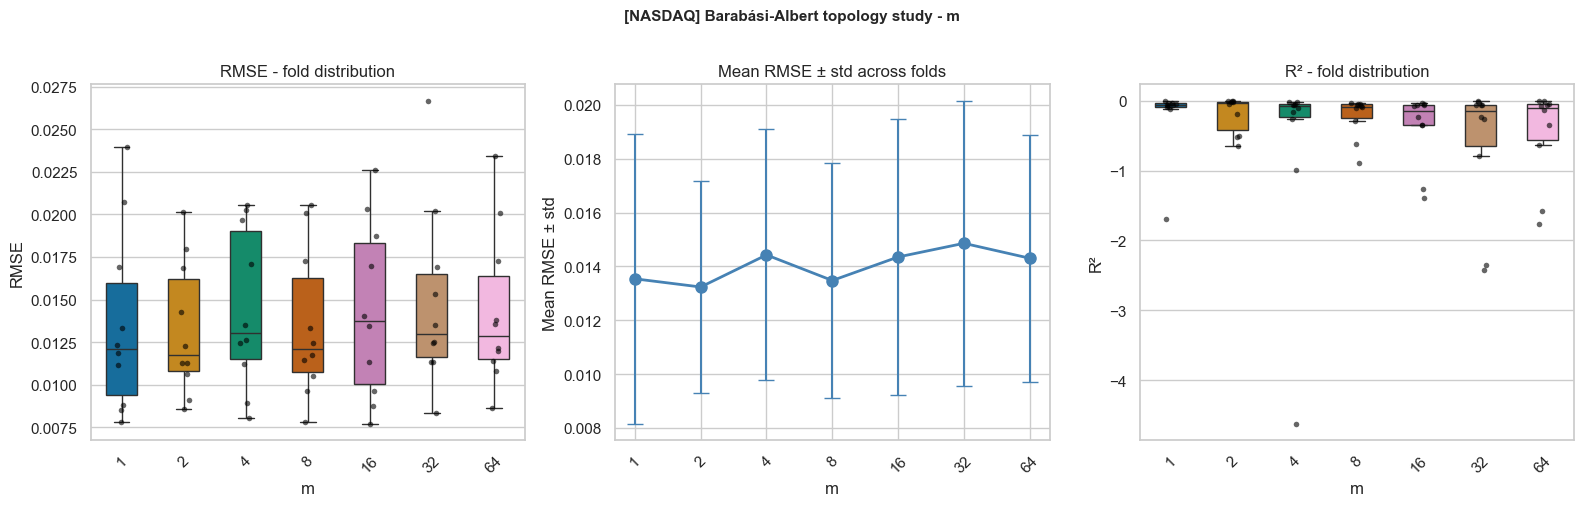

In [61]:
# ---------------------------------------------------------------------------
# 6.3 Barabási-Albert - sensitivity to m
# ---------------------------------------------------------------------------
ba_m_values = []
m_val = 1
while m_val < PHASE_B_PARAMS["N"]:
    ba_m_values.append(m_val)
    m_val *= 2

df_shs_ba_m = run_topology_shs(
    X_nasdaq,
    y_nasdaq,
    topology="scale_free",
    param_name="m",
    param_values=ba_m_values,
    esn_params=PHASE_B_PARAMS,
    save_csv=OUTPUT_DIR / "topo_scale_free_m.csv",
)

plot_single_hp(
    df_shs_ba_m,
    "m",
    ba_m_values,
    label_map={v: str(v) for v in ba_m_values},
    title=f"[NASDAQ] Barabási-Albert topology study - m",
    save_path=OUTPUT_DIR / "shs_m.png",
)


#### 6.3. Barabási-Albert (Scale-free) - Sensitivity to `m`

The Barabási-Albert family is useful because it changes density while simultaneously
introducing **hub structure**.

If the best regime occurs at very small `m`, the benchmark prefers sparse almost-tree-like
reservoirs. If a second dense regime becomes competitive, the result may reflect a more
global random-matrix effect rather than any small-world or hub-specific advantage.


Best ER  : p=0.001
Best WS  : k=2, p_rewire=0.5
Best BA  : m=2


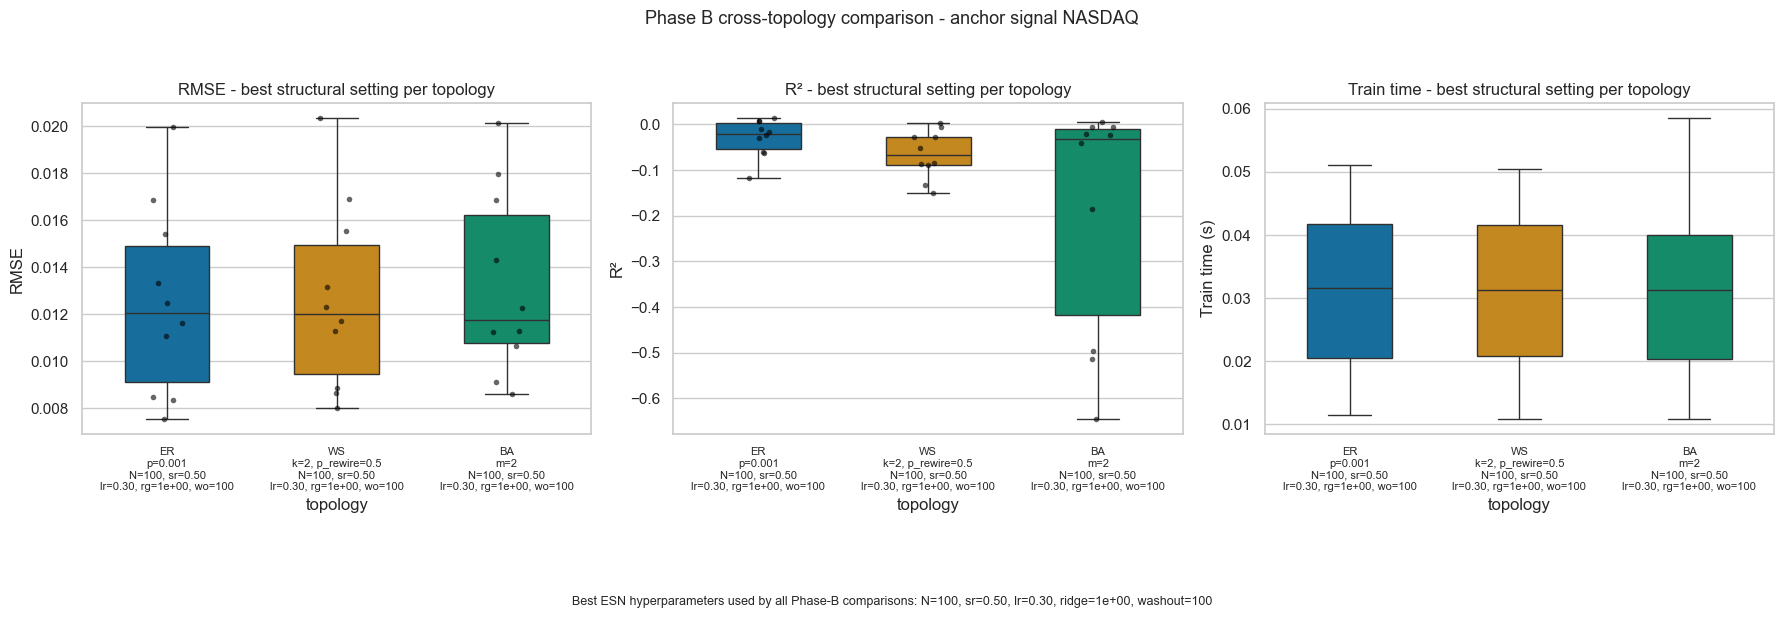

Best structural setting by topology

  ER : p=0.001
  WS : k=2, p_rewire=0.5
  BA : m=2

Best ESN hyperparameters used in Phase B: N=100, sr=0.50, lr=0.30, ridge=1e+00, washout=100

Cross-topology summary

        topology      Best_setting                              Best_ESN_hyperparams                                                            Best_model  RMSE_mean  RMSE_std  R2_mean  R2_std  Time_mean  Time_std
     ER (random)           p=0.001 N=100, sr=0.50, lr=0.30, ridge=1e+00, washout=100           p=0.001 | N=100, sr=0.50, lr=0.30, ridge=1e+00, washout=100    0.01250   0.00400 -0.02983 0.04052    0.03125   0.01382
WS (small-world) k=2, p_rewire=0.5 N=100, sr=0.50, lr=0.30, ridge=1e+00, washout=100 k=2, p_rewire=0.5 | N=100, sr=0.50, lr=0.30, ridge=1e+00, washout=100    0.01267   0.00396 -0.06590 0.05202    0.03114   0.01377
 BA (scale-free)               m=2 N=100, sr=0.50, lr=0.30, ridge=1e+00, washout=100               m=2 | N=100, sr=0.50, lr=0.30, ridge=1e+00, washout=1

In [62]:
# ---------------------------------------------------------------------------
# 6.4 Cross-topology comparison - best structural setting per topology
# ---------------------------------------------------------------------------
def extract_best(df, param_name, best_val, label):
    out = df[df[param_name] == best_val][["fold", "rmse", "r2", "mae", "train_time_s"]].copy()
    out["topology"] = label
    return out


def extract_best_ws(df, best_k, best_prw, label):
    out = df[(df["k"] == best_k) & (df["p_rewire"] == best_prw)][["fold", "rmse", "r2", "mae", "train_time_s"]].copy()
    out["topology"] = label
    return out


best_er_p = best_setting(df_shs_er_p, "p")
best_ba_m = best_setting(df_shs_ba_m, "m")

print(f"Best ER  : p={best_er_p}")
print(f"Best WS  : k={best_ws_k}, p_rewire={best_ws_prw}")
print(f"Best BA  : m={best_ba_m}")

df_cross = pd.concat(
    [
        extract_best(df_shs_er_p, "p", best_er_p, "ER (random)"),
        extract_best_ws(df_ws_grid, best_ws_k, best_ws_prw, "WS (small-world)"),
        extract_best(df_shs_ba_m, "m", best_ba_m, "BA (scale-free)"),
    ],
    ignore_index=True,
)

topo_order = ["ER (random)", "WS (small-world)", "BA (scale-free)"]
best_setting_labels = {
    "ER (random)": f"p={best_er_p:.3g}",
    "WS (small-world)": f"k={int(best_ws_k)}, p_rewire={best_ws_prw:.3g}",
    "BA (scale-free)": f"m={int(best_ba_m)}",
}
best_esn_params_str = (
    f"N={PHASE_B_PARAMS['N']}, sr={PHASE_B_PARAMS['sr']:.2f}, lr={PHASE_B_PARAMS['lr']:.2f}, "
    f"ridge={PHASE_B_PARAMS['ridge']:.0e}, washout={PHASE_B_PARAMS['washout']}"
)
best_esn_params_multiline = (
    f"N={PHASE_B_PARAMS['N']}, sr={PHASE_B_PARAMS['sr']:.2f}\n"
    f"lr={PHASE_B_PARAMS['lr']:.2f}, rg={PHASE_B_PARAMS['ridge']:.0e}, wo={PHASE_B_PARAMS['washout']}"
)
best_model_labels = {
    topo: f"{best_setting_labels[topo]} | {best_esn_params_str}"
    for topo in topo_order
}
xtick_labels = [
    f"ER\n{best_setting_labels['ER (random)']}\n{best_esn_params_multiline}",
    f"WS\n{best_setting_labels['WS (small-world)']}\n{best_esn_params_multiline}",
    f"BA\n{best_setting_labels['BA (scale-free)']}\n{best_esn_params_multiline}",
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6.2))

sns.boxplot(data=df_cross, x="topology", y="rmse", order=topo_order, palette="colorblind", width=0.5, fliersize=0, ax=axes[0])
sns.stripplot(data=df_cross, x="topology", y="rmse", order=topo_order, color="black", size=4, alpha=0.6, jitter=True, ax=axes[0])
axes[0].set_title("RMSE - best structural setting per topology")
axes[0].set_ylabel("RMSE")
axes[0].set_xticklabels(xtick_labels, fontsize=8)

sns.boxplot(data=df_cross, x="topology", y="r2", order=topo_order, palette="colorblind", width=0.5, fliersize=0, ax=axes[1])
sns.stripplot(data=df_cross, x="topology", y="r2", order=topo_order, color="black", size=4, alpha=0.6, jitter=True, ax=axes[1])
axes[1].set_title("R² - best structural setting per topology")
axes[1].set_ylabel("R²")
axes[1].set_xticklabels(xtick_labels, fontsize=8)

sns.boxplot(data=df_cross, x="topology", y="train_time_s", order=topo_order, palette="colorblind", width=0.5, fliersize=0, ax=axes[2])
axes[2].set_title("Train time - best structural setting per topology")
axes[2].set_ylabel("Train time (s)")
axes[2].set_xticklabels(xtick_labels, fontsize=8)

fig.text(0.5, 0.02, f"Best ESN hyperparameters used by all Phase-B comparisons: {best_esn_params_str}", ha="center", fontsize=9)
plt.suptitle(f"Phase B cross-topology comparison - anchor signal {"NASDAQ"}", fontsize=13)
plt.tight_layout(rect=[0, 0.14, 1, 0.95])
plt.savefig(OUTPUT_DIR / "phase_b_cross_topology_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

phase_b_summary = (
    df_cross.groupby("topology")[["rmse", "r2", "train_time_s"]]
    .agg(["mean", "std"])
    .reindex(topo_order)
)
phase_b_summary.columns = [
    "RMSE_mean", "RMSE_std",
    "R2_mean", "R2_std",
    "Time_mean", "Time_std",
]
phase_b_summary = phase_b_summary.reset_index()
phase_b_summary["Best_setting"] = phase_b_summary["topology"].map(best_setting_labels)
phase_b_summary["Best_ESN_hyperparams"] = best_esn_params_str
phase_b_summary["Best_model"] = phase_b_summary["topology"].map(best_model_labels)
phase_b_summary = phase_b_summary[
    [
        "topology", "Best_setting", "Best_ESN_hyperparams", "Best_model",
        "RMSE_mean", "RMSE_std", "R2_mean", "R2_std", "Time_mean", "Time_std",
    ]
]
phase_b_summary.to_csv(OUTPUT_DIR / "phase_b_cross_topology_summary.csv", index=False)

best_topology_params = {
    "ER": {"topology": "random", "params": {"p": float(best_er_p)}},
    "WS": {"topology": "small_world", "params": {"k": int(best_ws_k), "p_rewire": float(best_ws_prw)}},
    "BA": {"topology": "scale_free", "params": {"m": int(best_ba_m)}},
}

print("Best structural setting by topology\n")
print(f"  ER : {best_setting_labels['ER (random)']}")
print(f"  WS : {best_setting_labels['WS (small-world)']}")
print(f"  BA : {best_setting_labels['BA (scale-free)']}")
print(f"\nBest ESN hyperparameters used in Phase B: {best_esn_params_str}")
print("\nCross-topology summary\n")
print(phase_b_summary.to_string(index=False, float_format=lambda x: f"{x:.5f}"))


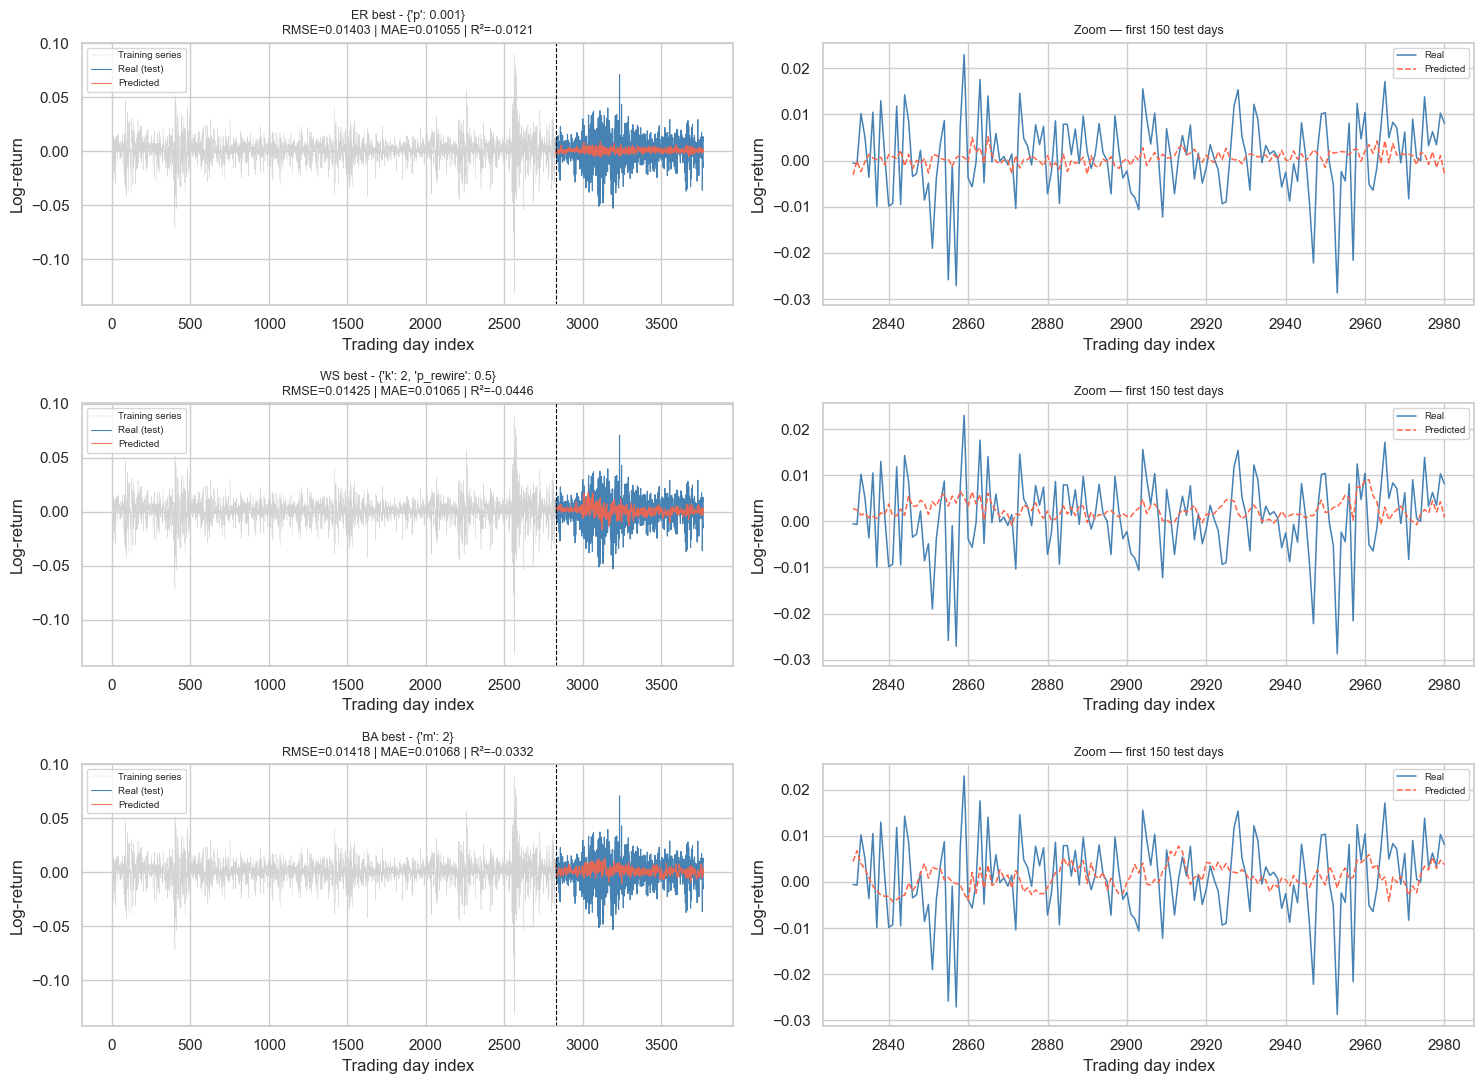

Figure saved  single_hp_outputs_4/phase_b_best_topology_prediction_grid.png


In [63]:
# ---------------------------------------------------------------------------
# Held-out prediction comparison with the best topology of each family
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(15, 11))

er_W, _ = make_reservoir_matrix(PHASE_B_PARAMS["N"], "random", best_topology_params["ER"]["params"])
ws_W, _ = make_reservoir_matrix(PHASE_B_PARAMS["N"], "small_world", best_topology_params["WS"]["params"])
ba_W, _ = make_reservoir_matrix(PHASE_B_PARAMS["N"], "scale_free", best_topology_params["BA"]["params"])

plot_nasdaq_prediction(
    PHASE_B_PARAMS,
    title=f"ER best - {best_topology_params['ER']['params']}",
    W_custom=er_W,
    ax_row=axes[0],
)
plot_nasdaq_prediction(
    PHASE_B_PARAMS,
    title=f"WS best - {best_topology_params['WS']['params']}",
    W_custom=ws_W,
    ax_row=axes[1],
)
plot_nasdaq_prediction(
    PHASE_B_PARAMS,
    title=f"BA best - {best_topology_params['BA']['params']}",
    W_custom=ba_W,
    ax_row=axes[2],
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase_b_best_topology_prediction_grid.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Figure saved  {OUTPUT_DIR / 'phase_b_best_topology_prediction_grid.png'}")


<br>

---

## 7. Conclusions

### 7.1. Phase A — Hyperparameter study

The NASDAQ log-return series is a substantially harder forecasting target than the ERA5
temperature or the controlled synthetic benchmark. Daily returns have little exploitable
autocorrelation structure, so the ESN must largely rely on **volatility persistence** (the
tendency for large absolute returns to cluster) rather than oscillatory patterns.

Key findings from the OAT sensitivity analysis mirror those of Notebook 2:
- **Reservoir size (N)** shows the expected diminishing-returns curve once the reservoir
  is large enough to span the relevant short-lag structure.
- **Spectral radius (sr)** near the near-critical regime (around 0.9–1.1) typically provides
  the best fading-memory balance.
- **Leak rate (lr)** has a strong effect: very small values freeze the reservoir state,
  while values close to 1 make it forget too quickly for financial volatility dynamics.
- **Ridge regularisation** matters for numerical stability but the optimal region is broad.
- **Washout** has little impact beyond a small initial transient.

### 7.2. Phase B — Topology study

The topology study isolates how **graph structure** modulates forecasting performance when
the ESN hyperparameters are fixed. On the NASDAQ series:
- **ER (random)** reservoirs serve as the neutral baseline.
- **WS (small-world)** reservoirs may improve performance if the optimal `(k, p_rewire)`
  setting provides a useful combination of local clustering and global information mixing.
- **BA (scale-free)** reservoirs introduce hub nodes that can concentrate or distribute
  information differently from the other families.

The cross-topology comparison shows which structural family best exploits the available
short-lag structure in NASDAQ log-returns, complementing the results from Notebooks 1–3.
